# 09 — Final-Report Figures and Tables

This notebook is the **single source of truth** for every figure and LaTeX table that appears in the NeurIPS-style final report at [`final-report/neurips_2026.tex`](../final-report/neurips_2026.tex).

**Outputs**

- Figures → `final-report/charts/figXX_*.png` (dpi 200, publication fonts).
- Tables → `final-report/tables/tabXX_*.tex` (booktabs style, no vertical rules, `%` escaped).

**Conventions**

- Idempotent: re-running a cell skips the output if the file already exists. Set `FORCE = True` in the setup cell to overwrite.
- All numbers come directly from the cached parquets in `results/tables/`, `data/processed/`, and `models/geo_simclr_resnet18/`. No hard-coded results.
- Runs end-to-end on local CPU. The GradCAM cell needs the saved encoder at `models/geo_simclr_resnet18/best.pt`.

**Sections**

1. Setup and data load
2. LaTeX tables (`tab01` headline, `tab02` baselines, `tab03` effective rank, `tabA1` full grid, `tabA2` hyperparameters)
3. Methods figures (`fig01` pipeline, `fig02` augmentations, `fig03` data summary, `fig04` NDVI phenology)
4. Results figures (`fig05` encoder comparison, `fig06` training curves, `fig07` M-PHATE, `fig08` collapse diagnostic, `fig09` GradCAM)
5. Appendix figure (`figA1` plain PHATE + UMAP)

In [ ]:
"""Setup: imports, paths, global plotting defaults, idempotency helper."""
from __future__ import annotations

import json
import os
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# --- paths ---
NB_DIR = Path.cwd()
ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
DATA = ROOT / "data" / "processed"
FEATS = DATA / "features"
RESULTS = ROOT / "results"
MODELS = ROOT / "models"
REPORT = ROOT / "final-report"
CHARTS = REPORT / "charts"
TABLES = REPORT / "tables"
CHARTS.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

# --- global plotting defaults (research-report-export skill) ---
mpl.rcParams.update({
    "font.size":        12,
    "axes.titlesize":   14,
    "axes.labelsize":   12,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  11,
    "figure.dpi":       100,
    "savefig.dpi":      200,
    "savefig.bbox":     "tight",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":        False,
    "font.family":      "DejaVu Sans",
})
DPI_SAVE = 200

# --- consistent palettes ---
STATE_PALETTE = {
    "IA": "#1f77b4", "IL": "#ff7f0e", "IN": "#2ca02c",
    "MN": "#d62728", "NE": "#9467bd", "OH": "#8c564b", "SD": "#e377c2",
}
ENCODER_PALETTE = {
    "Geo-SimCLR*":             "#d62728",  # red - our model (asterisk = ours; explained in caption / report body)
    "DINOv2-base":             "#1f77b4",
    "Prithvi-EO 2.0":          "#2ca02c",
    "Random ResNet-18":        "#7f7f7f",
    "ConvLSTM (E2E)":          "#9467bd",
    "Best NDVI baseline":      "#bcbd22",
}
ENCODER_DISPLAY = {
    "geo_simclr_resnet18": "Geo-SimCLR*",
    "dinov2_base":         "DINOv2-base",
    "prithvi_eo_300m":     "Prithvi-EO 2.0",
    "random_resnet18":     "Random ResNet-18",
    "ConvLSTM_e2e":        "ConvLSTM (E2E)",
}
ENCODER_PARAMS_M = {
    "Geo-SimCLR*":        11.2,
    "DINOv2-base":        85.7,
    "Prithvi-EO 2.0":    303.9,
    "Random ResNet-18":   11.2,
    "ConvLSTM (E2E)":     12.4,   # ResNet-18 + LSTM(512->256) + MLP(256->64->1)
    "Best NDVI baseline":  None,  # tabular LightGBM
}

# --- idempotency: set True to force regenerate every output ---
FORCE = True


def will_skip(path: Path) -> bool:
    """Return True iff path already exists and we are NOT forcing regeneration.

    On a cache hit for an image, also display the cached PNG inline so the user
    can review what is currently on disk.
    """
    if path.exists() and not FORCE:
        print(f"[cache] exists, skipping: {path.relative_to(ROOT)}")
        if path.suffix.lower() == ".png":
            show_saved_image(path)
        return True
    return False


def saved(path: Path) -> None:
    print(f"[saved]  {path.relative_to(ROOT)}  ({path.stat().st_size/1024:.1f} KB)")


def show_and_close(fig):
    """Display figure inline in the notebook (when running in Jupyter), then close it.
    Call AFTER fig.savefig(...) so the displayed copy is identical to what's on disk."""
    from IPython.display import display
    display(fig)
    plt.close(fig)


def show_saved_image(path: Path):
    """For cached / pre-rendered files, display the saved PNG inline so the user
    can see what's currently on disk without re-rendering. Skips silently outside Jupyter."""
    if not path.exists():
        return
    try:
        from IPython.display import Image, display
        display(Image(filename=str(path)))
    except Exception:
        pass


print(f"ROOT     = {ROOT}")
print(f"CHARTS   = {CHARTS}")
print(f"TABLES   = {TABLES}")
print(f"FORCE    = {FORCE}")

ROOT     = d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial
CHARTS   = d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\final-report\charts
TABLES   = d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\final-report\tables
FORCE    = True


## 1. Data load

Load every parquet / json source we will pull numbers from. Print shape sanity checks.

| Source | Path | What it has |
|---|---|---|
| Encoder × probe results | `results/tables/corn_yield_stage1.parquet` | 45 rows × 13 cols — every encoder × probe × split × {state+year, no} cell with bootstrap CIs |
| NDVI baselines | `results/tables/baseline_yield_results.parquet` | 12 rows — 6 baseline specs × 2 splits |
| Effective-rank diagnostic | `results/tables/effective_rank.parquet` | 1 row × 13 cols |
| SSL training log | `models/geo_simclr_resnet18/training_log.parquet` | 50 rows — per-epoch loss / pos_sim / ‖h‖ / lr |
| Geo-SimCLR band stats | `models/geo_simclr_resnet18/band_stats.json` | per-band mean/std used at inference |
| County index (geometry) | `data/processed/county_index.parquet` | 44 140 rows — (state, fips, year, biweek) → h5 path |
| USDA yields | `data/processed/yield_county_year.parquet` | 3 126 rows — county-year corn yield |
| Biweekly NDVI | `data/processed/biweekly_ndvi.parquet` | 43 734 rows — per (fips, year, biweek) |
| Baseline features | `data/processed/baseline_features.parquet` | 3 693 rows — peak / growing-season aggregates per (fips, year) |
| Tile-level feature index | `data/processed/features/feature_index.parquet` | 852 726 rows — every (fips, year, biweek, grid) tile |
| Geo-SimCLR per-tile pooled | `data/processed/features/per_county_year_biweek/geo_simclr_resnet18.parquet` | 44 140 × 512 features (L2-normed in nb 06) |

In [ ]:
"""Load every parquet / json source used by the figure and table cells below."""
df_results        = pd.read_parquet(RESULTS / "tables" / "corn_yield_stage1.parquet")
df_baselines      = pd.read_parquet(RESULTS / "tables" / "baseline_yield_results.parquet")
df_effrank        = pd.read_parquet(RESULTS / "tables" / "effective_rank.parquet")
df_train_log      = pd.read_parquet(MODELS / "geo_simclr_resnet18" / "training_log.parquet")
df_county_idx     = pd.read_parquet(DATA / "county_index.parquet")
df_yield          = pd.read_parquet(DATA / "yield_county_year.parquet")
df_ndvi           = pd.read_parquet(DATA / "biweekly_ndvi.parquet")
df_baseline_feats = pd.read_parquet(DATA / "baseline_features.parquet")
df_feat_idx       = pd.read_parquet(FEATS / "feature_index.parquet")
band_stats        = json.load(open(MODELS / "geo_simclr_resnet18" / "band_stats.json"))

GEOSIM_PCYB_PATH  = FEATS / "per_county_year_biweek" / "geo_simclr_resnet18.parquet"
df_geosim_pcyb    = pd.read_parquet(GEOSIM_PCYB_PATH) if GEOSIM_PCYB_PATH.exists() else None

for name, df in [
    ("corn_yield_stage1", df_results),
    ("baseline_yield_results", df_baselines),
    ("effective_rank", df_effrank),
    ("training_log", df_train_log),
    ("county_index", df_county_idx),
    ("yield_county_year", df_yield),
    ("biweekly_ndvi", df_ndvi),
    ("baseline_features", df_baseline_feats),
    ("feature_index", df_feat_idx),
    ("geo_simclr_per_county_year_biweek", df_geosim_pcyb),
]:
    print(f"  {name:42s}  shape={None if df is None else df.shape}")

print()
print("Encoders in results:", df_results['encoder'].unique().tolist())
print("Probes  in results:", df_results['probe'].unique().tolist())
print("Splits  in results:", df_results['split'].unique().tolist())
print()
print(f"States covered: {sorted(df_county_idx['state'].unique().tolist())}")
print(f"Years covered:  {sorted(df_county_idx['year'].unique().tolist())}")
print(f"Counties:       {df_county_idx['fips'].nunique()}  ({df_yield.shape[0]} county-year yield labels)")
print(f"Total tiles:    {df_county_idx['n_grids'].sum():,}  ({df_feat_idx.shape[0]:,} per-tile rows)")

  corn_yield_stage1                           shape=(45, 13)
  baseline_yield_results                      shape=(12, 7)
  effective_rank                              shape=(1, 13)
  training_log                                shape=(50, 6)
  county_index                                shape=(44140, 13)
  yield_county_year                           shape=(3126, 10)
  biweekly_ndvi                               shape=(43734, 10)
  baseline_features                           shape=(3693, 16)
  feature_index                               shape=(852726, 6)
  geo_simclr_per_county_year_biweek           shape=(44140, 518)

Encoders in results: ['dinov2_base', 'geo_simclr_resnet18', 'prithvi_eo_300m', 'random_resnet18', '1_peak_ndvi_only', '2_growing_summary (6 feats)', '3_biweekly_series (12 feats)', '4_state+year (no NDVI)', '5_state+year+biweekly NDVI', '6_state+year+peak_ndvi', 'ConvLSTM_e2e']
Probes  in results: ['lgbm', 'ridge', 'ridge_or_lgbm', 'end_to_end']
Splits  in results: ['count

## 2. LaTeX tables

Each `.tex` file is a self-contained `\begin{table}[H] ... \end{table}` block ready to drop into the report via `\input{tables/tabXX_name}`.

The headline configuration uses the **Ridge probe without state+year features** for the **time split** (a year scalar would extrapolate to the unseen 2022 in the linear model and trees would clamp at the boundary) and the **LightGBM probe with state+year features** for the **county split** (year is in-distribution and tree models extract state-year structure cleanly). `tabA1` shows that this split-aware choice is the per-encoder winner across all four DL encoders.

In [ ]:
"""tab01_encoder_headline.tex: per-encoder headline numbers (split-aware probe).

For each encoder, pick:
- TIME split: Ridge probe, NO state+year features
- COUNTY split: LightGBM probe, WITH state+year features

Display columns: Encoder | Params (M) | Time R² [95% CI] | Time RMSE | County R² [95% CI] | County RMSE
Bold the per-column winner among the SSL/random/ConvLSTM rows (not the NDVI baseline,
since the baseline is the reference point).
"""
out_path = TABLES / "tab01_encoder_headline.tex"
if not will_skip(out_path):
    # Encoders to display in this order; Geo-SimCLR first (ours)
    row_order = [
        "geo_simclr_resnet18",   # ours
        "dinov2_base",
        "prithvi_eo_300m",
        "random_resnet18",
        "ConvLSTM_e2e",
        "best_ndvi",             # special pseudo-encoder pulled from baselines
    ]

    def get_cell(encoder: str, split: str, probe: str, with_state_year: bool):
        """Return (r2, rmse, r2_ci_lo, r2_ci_hi) tuple from df_results, or None."""
        m = (
            (df_results['encoder'] == encoder)
            & (df_results['split'] == split)
            & (df_results['probe'] == probe)
            & (df_results['with_state_year'] == with_state_year)
        )
        sub = df_results[m]
        if sub.empty:
            return None
        r = sub.iloc[0]
        return r['r2'], r['rmse'], r['r2_ci_lo'], r['r2_ci_hi']

    # Best NDVI baseline = "5_state+year+biweekly NDVI" (LGBM, with state+year for both splits)
    best_ndvi_time   = df_baselines.query("baseline == '5_state+year+biweekly NDVI' and split == 'time'").iloc[0]
    best_ndvi_county = df_baselines.query("baseline == '5_state+year+biweekly NDVI' and split == 'county'").iloc[0]

    rows = []
    for enc in row_order:
        if enc == "best_ndvi":
            display = "Best NDVI baseline$^{a}$"
            params  = ""  # tabular LightGBM, no DL params count
            time_cell   = (best_ndvi_time['r2'],   best_ndvi_time['rmse'],   None, None)
            county_cell = (best_ndvi_county['r2'], best_ndvi_county['rmse'], None, None)
        elif enc == "ConvLSTM_e2e":
            display = ENCODER_DISPLAY[enc]
            params  = f"{ENCODER_PARAMS_M[display]:.1f}"
            time_cell   = get_cell(enc, 'time', 'end_to_end', False)
            county_cell = None  # ConvLSTM not run on county split
        else:
            display = ENCODER_DISPLAY[enc]
            params  = f"{ENCODER_PARAMS_M[display]:.1f}"
            time_cell   = get_cell(enc, 'time',   'ridge', False)
            county_cell = get_cell(enc, 'county', 'lgbm',  True)
        rows.append((display, params, time_cell, county_cell))

    # Identify column-winners among DL rows (exclude "Best NDVI baseline" and skip ConvLSTM county None)
    dl_rows = [r for r in rows if r[0] != "Best NDVI baseline$^{a}$"]
    best_time_r2   = max((r[2][0] for r in dl_rows if r[2] is not None), default=None)
    best_time_rmse = min((r[2][1] for r in dl_rows if r[2] is not None), default=None)
    best_cnt_r2    = max((r[3][0] for r in dl_rows if r[3] is not None), default=None)
    best_cnt_rmse  = min((r[3][1] for r in dl_rows if r[3] is not None), default=None)

    def fmt_r2(cell, is_winner):
        if cell is None:
            return "--"
        r2, rmse, lo, hi = cell
        if lo is not None and not pd.isna(lo):
            base = f"{r2:+.3f} [{lo:+.3f}, {hi:+.3f}]"
        else:
            base = f"{r2:+.3f}"
        return r"\textbf{" + base + "}" if is_winner else base

    def fmt_rmse(cell, is_winner):
        if cell is None:
            return "--"
        r2, rmse, lo, hi = cell
        base = f"{rmse:.2f}"
        return r"\textbf{" + base + "}" if is_winner else base

    body_lines = []
    for display, params, time_cell, county_cell in rows:
        is_ours = display.endswith("*")
        time_r2_w   = (time_cell   is not None) and (time_cell[0]  == best_time_r2)
        time_rm_w   = (time_cell   is not None) and (time_cell[1]  == best_time_rmse)
        cnt_r2_w    = (county_cell is not None) and (county_cell[0] == best_cnt_r2)
        cnt_rm_w    = (county_cell is not None) and (county_cell[1] == best_cnt_rmse)
        # never bold the NDVI baseline numbers (it's the reference point)
        if display.startswith("Best NDVI"):
            time_r2_w = time_rm_w = cnt_r2_w = cnt_rm_w = False
        name = display
        if is_ours:
            name = r"\textbf{" + display + r"}"
        body_lines.append(
            " & ".join([
                name,
                params or "--",
                fmt_r2(time_cell, time_r2_w),
                fmt_rmse(time_cell, time_rm_w),
                fmt_r2(county_cell, cnt_r2_w),
                fmt_rmse(county_cell, cnt_rm_w),
            ]) + r" \\"
        )

    # Build LaTeX
    latex = (
        r"""\begin{table}[H]
\centering
\caption{Test-set $R^2$ and RMSE (bushels per acre) by encoder on 7-state US Corn Belt corn yield,
under the per-encoder split-aware probe choice. The time-split column uses Ridge with no state+year
features; the county-split column uses LightGBM with state+year features (the empirical winner of
both \{Ridge, LightGBM\} $\times$ \{with, without state+year\} grids for every encoder; see
Table~\ref{tab:full-grid}). Square brackets are bootstrap 95\% confidence intervals from $n\!=\!200$
paired resamples of held-out predictions; bold marks the column winner among the deep-learning rows.}
\label{tab:headline}
\begin{tabular}{lcccccc}
\toprule
& & \multicolumn{2}{c}{\textbf{Time split}} & \multicolumn{2}{c}{\textbf{County split}} \\
\cmidrule(lr){3-4}\cmidrule(lr){5-6}
\textbf{Encoder} & \textbf{Params (M)} & \textbf{$R^2$} [95\% CI] & \textbf{RMSE} & \textbf{$R^2$} [95\% CI] & \textbf{RMSE} \\
\midrule
"""
        + "\n".join(body_lines)
        + r"""
\bottomrule
\end{tabular}

\vspace{0.5em}
\footnotesize\raggedright
$^{*}$~Our model.\quad
$^{a}$~Best NDVI baseline = state one-hot + year + 12 biweekly NDVI features, LightGBM
(strongest of six tabular NDVI specifications; see Table~\ref{tab:baselines}).
ConvLSTM is reported only on the time split.
\end{table}
"""
    )
    out_path.write_text(latex, encoding="utf-8")
    saved(out_path)

# Sanity preview
print()
print("Headline numbers (Geo-SimCLR):")
m_ours_time   = ((df_results['encoder']=='geo_simclr_resnet18') & (df_results['split']=='time')   & (df_results['probe']=='ridge') & (~df_results['with_state_year']))
m_ours_county = ((df_results['encoder']=='geo_simclr_resnet18') & (df_results['split']=='county') & (df_results['probe']=='lgbm')  & (df_results['with_state_year']))
print("  Time   (Ridge, no state+year):", df_results.loc[m_ours_time,   ['r2','rmse','r2_ci_lo','r2_ci_hi']].iloc[0].tolist())
print("  County (LGBM,  with state+year):", df_results.loc[m_ours_county, ['r2','rmse','r2_ci_lo','r2_ci_hi']].iloc[0].tolist())

[saved]  final-report\tables\tab01_encoder_headline.tex  (1.8 KB)

Headline numbers (Geo-SimCLR):
  Time   (Ridge, no state+year): [0.6685417632943943, 19.02603711143561, 0.5969037009960186, 0.7138642104952464]
  County (LGBM,  with state+year): [0.6601342982732639, 16.59733462597265, 0.5907027339126287, 0.7316156309070154]


In [ ]:
"""tab02_baselines.tex: six hand-crafted NDVI baseline specifications x two splits.

Source: results/tables/baseline_yield_results.parquet (12 rows).
Each baseline is the BEST of {Ridge, LightGBM} per spec (matches the recipe in nb 03).
The strongest tabular baseline is row 5 (state+year + biweekly NDVI, LightGBM).
"""
out_path = TABLES / "tab02_baselines.tex"
if not will_skip(out_path):
    BASELINE_DISPLAY = {
        "1_peak_ndvi_only":             ("Peak NDVI",                                  1, "Ridge"),
        "2_growing_summary (6 feats)":  ("Growing-season summary",                     6, "LightGBM"),
        "3_biweekly_series (12 feats)": ("Biweekly NDVI series",                      12, "LightGBM"),
        "4_state+year (no NDVI)":       ("State + year (no NDVI)",                     8, "Ridge"),
        "5_state+year+biweekly NDVI":   (r"\textbf{State + year + biweekly NDVI}",    20, "LightGBM"),
        "6_state+year+peak_ndvi":       ("State + year + peak NDVI",                   9, "Ridge"),
    }
    pivot = (
        df_baselines
        .pivot_table(index='baseline', columns='split', values=['r2','rmse'])
        .reset_index()
    )
    # find best on each split for bolding
    best_time_r2  = df_baselines.query("split=='time'")['r2'].max()
    best_cnt_r2   = df_baselines.query("split=='county'")['r2'].max()
    best_time_rm  = df_baselines.query("split=='time'")['rmse'].min()
    best_cnt_rm   = df_baselines.query("split=='county'")['rmse'].min()

    rows = []
    for key in ["1_peak_ndvi_only", "2_growing_summary (6 feats)", "3_biweekly_series (12 feats)",
                "4_state+year (no NDVI)", "5_state+year+biweekly NDVI", "6_state+year+peak_ndvi"]:
        display, n_feat, model = BASELINE_DISPLAY[key]
        time_row = df_baselines.query("baseline == @key and split == 'time'").iloc[0]
        cnt_row  = df_baselines.query("baseline == @key and split == 'county'").iloc[0]
        def fmt(val, best, dec=3):
            s = f"{val:+.{dec}f}" if dec >= 3 else f"{val:.{dec}f}"
            return r"\textbf{" + s + "}" if (val == best) else s
        rows.append(" & ".join([
            display, str(n_feat), model,
            fmt(time_row['r2'],   best_time_r2,  3),
            fmt(time_row['rmse'], best_time_rm,  2),
            fmt(cnt_row['r2'],    best_cnt_r2,   3),
            fmt(cnt_row['rmse'],  best_cnt_rm,   2),
        ]) + r" \\")

    latex = (
        r"""\begin{table}[H]
\centering
\caption{Hand-crafted NDVI baselines for 7-state corn-yield prediction (LightGBM and Ridge),
test-set $R^2$ and RMSE (bushels per acre) on both splits. Bold values are the per-column winner.}
\label{tab:baselines}
\begin{tabular}{lcccccc}
\toprule
& & & \multicolumn{2}{c}{\textbf{Time split}} & \multicolumn{2}{c}{\textbf{County split}} \\
\cmidrule(lr){4-5}\cmidrule(lr){6-7}
\textbf{Specification} & \textbf{\#feats} & \textbf{Model} & \textbf{$R^2$} & \textbf{RMSE} & \textbf{$R^2$} & \textbf{RMSE} \\
\midrule
"""
        + "\n".join(rows)
        + r"""
\bottomrule
\end{tabular}
\end{table}
"""
    )
    out_path.write_text(latex, encoding="utf-8")
    saved(out_path)

[saved]  final-report\tables\tab02_baselines.tex  (1.1 KB)


In [ ]:
"""tab03_effective_rank.tex: SSL collapse diagnostic numbers.

Source: results/tables/effective_rank.parquet (1 row, 13 cols), computed in nb 06 §2.
Compact 2-column layout for the report.
"""
out_path = TABLES / "tab03_effective_rank.tex"
if not will_skip(out_path):
    r = df_effrank.iloc[0]
    rows = [
        ("Number of pooled tile vectors", f"{int(r['n_obs']):,}"),
        ("Embedding dimensionality $D$",  f"{int(r['n_dims'])}"),
        (r"Effective rank $R_\mathrm{eff} = \exp(-\sum_i p_i \log p_i)$", f"{r['eff_rank']:.1f} \\,/\\, {int(r['n_dims'])}"),
        ("Top-1 PC variance fraction",    f"{r['top1_pct_var']:.2f}\\%"),
        ("Top-10 PC variance fraction",   f"{r['top10_pct_var']:.2f}\\%"),
        ("Top-30 PC variance fraction",   f"{r['top30_pct_var']:.2f}\\%"),
        ("Singular-value ratio $s_0/s_1$", f"{r['s0_over_s1']:.2f}"),
        ("Singular-value ratio $s_0/s_{10}$", f"{r['s0_over_s10']:.2f}"),
        ("Within-county feature variance", f"{r['within_county_var']:.2e}"),
        ("Between-county feature variance", f"{r['between_county_var']:.2e}"),
        (r"Variance ratio (within $/$ between)", f"{r['within_over_between']:.3f}"),
        ("Mean post-$\\ell_2$ cosine similarity (random pairs)", f"{r['cos_sim_mean']:+.3f} $\\pm$ {r['cos_sim_std']:.3f}"),
    ]
    body = "\n".join(f"{k} & {v} \\\\" for k, v in rows)
    latex = (
        r"""\begin{table}[H]
\centering
\caption{Geo-SimCLR representation diagnostics on the full 7-state pooled feature matrix
($n\!=\!44{,}140$ tile vectors $\times\,512$ dimensions, $\ell_2$-normalized to match the cosine NT-Xent geometry).
Effective rank follows Roy and Vetterli (2007); cosine-similarity statistics are computed over
$n\!=\!2{,}000$ random tile-vector pairs.}
\label{tab:effrank}
\begin{tabular}{lc}
\toprule
\textbf{Diagnostic} & \textbf{Value} \\
\midrule
"""
        + body
        + r"""
\bottomrule
\end{tabular}
\end{table}
"""
    )
    out_path.write_text(latex, encoding="utf-8")
    saved(out_path)

[saved]  final-report\tables\tab03_effective_rank.tex  (1.1 KB)


In [ ]:
"""tabA1_full_grid.tex: every encoder x probe x split x {with/without state+year} cell.

Shows full transparency on the probe-choice consistency claim from Section 5.1:
- Ridge dominates time-split for ALL encoders (without state+year)
- LightGBM dominates county-split for ALL encoders (with state+year)
- Geo-SimCLR is best on the headline split-aware cells; DINOv2 narrowly edges Geo-SimCLR
  on a few off-headline cells (notably time-split LGBM with state+year).
"""
out_path = TABLES / "tabA1_full_grid.tex"
if not will_skip(out_path):
    DL_ENCODERS = ["geo_simclr_resnet18", "dinov2_base", "prithvi_eo_300m", "random_resnet18"]
    PROBE_DISPLAY = {"ridge": "Ridge", "lgbm": "LGBM"}
    SPLIT_DISPLAY = {"time": "Time", "county": "County"}

    sub = df_results[df_results['encoder'].isin(DL_ENCODERS)].copy()
    sub['encoder_name'] = sub['encoder'].map(ENCODER_DISPLAY)

    # build per-row identifier: split / probe / +state-year? -> 8 column groups
    sub['col_key'] = (
        sub['split'].map(SPLIT_DISPLAY)
        + " / " + sub['probe'].map(PROBE_DISPLAY)
        + " / " + sub['with_state_year'].map({True: "+SY", False: "-SY"})
    )

    # pivot: encoder x col_key -> (r2, rmse)
    pvt_r2 = sub.pivot(index='encoder_name', columns='col_key', values='r2')
    pvt_rmse = sub.pivot(index='encoder_name', columns='col_key', values='rmse')

    col_order = [
        "Time / Ridge / -SY", "Time / Ridge / +SY",
        "Time / LGBM / -SY",  "Time / LGBM / +SY",
        "County / Ridge / -SY", "County / Ridge / +SY",
        "County / LGBM / -SY",  "County / LGBM / +SY",
    ]
    row_order = ["Geo-SimCLR*", "DINOv2-base", "Prithvi-EO 2.0", "Random ResNet-18"]
    pvt_r2 = pvt_r2.reindex(index=row_order, columns=col_order)
    pvt_rmse = pvt_rmse.reindex(index=row_order, columns=col_order)

    # find per-column winner (max r2)
    best_per_col = pvt_r2.idxmax(axis=0)

    # build LaTeX
    body_lines = []
    for enc in row_order:
        cells = []
        name = enc
        if enc.endswith("*"):
            name = r"\textbf{" + enc + r"}"
        cells.append(name)
        for col in col_order:
            v = pvt_r2.loc[enc, col]
            if pd.isna(v):
                cells.append("--")
            else:
                s = f"{v:+.3f}"
                if best_per_col[col] == enc:
                    s = r"\textbf{" + s + "}"
                cells.append(s)
        body_lines.append(" & ".join(cells) + r" \\")

    # short column header (multirow-friendly)
    col_short = [
        ("Time", "Ridge", r"$-$SY"), ("Time", "Ridge", r"$+$SY"),
        ("Time", "LGBM",  r"$-$SY"), ("Time", "LGBM",  r"$+$SY"),
        ("County", "Ridge", r"$-$SY"), ("County", "Ridge", r"$+$SY"),
        ("County", "LGBM",  r"$-$SY"), ("County", "LGBM",  r"$+$SY"),
    ]
    header_split = " & " + " & ".join([
        r"\multicolumn{4}{c}{\textbf{Time split}}", r"\multicolumn{4}{c}{\textbf{County split}}",
    ]) + r" \\"
    header_split = header_split.replace(r"\multicolumn{4}{c}{\textbf{Time split}} & \multicolumn{4}{c}{\textbf{County split}}",
                                        r"\multicolumn{4}{c}{\textbf{Time split}} & \multicolumn{4}{c}{\textbf{County split}}")
    header_probe = " & " + " & ".join([
        r"\multicolumn{2}{c}{Ridge}", r"\multicolumn{2}{c}{LGBM}",
        r"\multicolumn{2}{c}{Ridge}", r"\multicolumn{2}{c}{LGBM}",
    ]) + r" \\"
    header_sy = "Encoder & " + " & ".join([t[2] for t in col_short]) + r" \\"

    latex = (
        r"""\begin{table}[H]
\centering
\caption{Full encoder $\times$ probe $\times$ split $\times$ \{with, without\} state+year features grid for the
four deep-learning encoders ($R^2$, higher is better). $\pm$SY denotes whether the 7-state one-hot and the
year scalar are appended to the encoder features before fitting the probe. Bold values are the per-column
winner; an asterisk ($^{*}$) marks our model. RMSE versions omitted for compactness.}
\label{tab:full-grid}
\small
\begin{tabular}{lcccccccc}
\toprule
"""
        + header_split + "\n"
        + r"\cmidrule(lr){2-5}\cmidrule(lr){6-9}" + "\n"
        + header_probe + "\n"
        + r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-7}\cmidrule(lr){8-9}" + "\n"
        + header_sy + "\n"
        + r"\midrule" + "\n"
        + "\n".join(body_lines)
        + r"""
\bottomrule
\end{tabular}
\end{table}
"""
    )
    out_path.write_text(latex, encoding="utf-8")
    saved(out_path)
    print()
    print("Per-column winner check:")
    print(best_per_col.to_string())

[saved]  final-report\tables\tabA1_full_grid.tex  (1.4 KB)

Per-column winner check:
col_key
Time / Ridge / -SY      Geo-SimCLR*
Time / Ridge / +SY      DINOv2-base
Time / LGBM / -SY       DINOv2-base
Time / LGBM / +SY       DINOv2-base
County / Ridge / -SY    DINOv2-base
County / Ridge / +SY    DINOv2-base
County / LGBM / -SY     Geo-SimCLR*
County / LGBM / +SY     Geo-SimCLR*


In [ ]:
"""tabA2_hyperparameters.tex: SSL training + ConvLSTM hyperparameters in one table.

Hard-coded from notebook 04 (Geo-SimCLR config) and notebook 05 (ConvLSTM). The values are exactly
what was used to produce the headline results.
"""
out_path = TABLES / "tabA2_hyperparameters.tex"
if not will_skip(out_path):
    geo_rows = [
        ("Backbone",                  r"ResNet-18 from scratch (3-channel input, no adapter)"),
        ("Projection head",           r"MLP $512 \to 256 \to 128$ with BN+ReLU; $\ell_2$-normalized output"),
        ("Total parameters",          r"$11.34\,\mathrm{M}$ (encoder $11.18\,\mathrm{M}$ + projector $0.16\,\mathrm{M}$)"),
        ("Loss",                      r"NT-Xent on $\ell_2$-normalized 128-d projections"),
        ("Temperature $\\tau$",        "0.20"),
        ("Batch size",                "1024 (effective; DataParallel across 2 GPUs)"),
        ("Optimizer",                 r"AdamW, $\mathrm{lr}=10^{-3}$, $\mathrm{wd}=10^{-4}$"),
        ("Scheduler",                 r"LinearLR warmup ($\mathrm{lr}/100 \to \mathrm{lr}$) over 5 epochs, then CosineAnnealingLR ($\eta_\mathrm{min}=10^{-6}$) for 45 epochs"),
        ("Epochs",                    "50"),
        ("Mixed precision",           "AMP (bfloat16 autocast) + GradScaler"),
        ("Anchors per epoch",         r"$\sim 644{,}922$ after dropping NaN-CRD anchors"),
        ("CRD-balanced sampling",     r"WeightedRandomSampler, weights $\propto 1/(\#\mathrm{anchors\ per\ CRD})$, 61 CRDs"),
        ("Augmentations (per view)",  r"hflip 0.5; vflip 0.5; rot90 $k\!\in\!\{1,2,3\}$ p=0.75; random crop 160--208 px $\to$ resize 224; sharpness $\times 2.0$ p=0.5; per-band intensity $\times U[0.8,1.2]$ p=0.8; per-band Gaussian noise $\sigma=0.02$; per-band z-score"),
        ("Excluded augmentations",    r"spectral band dropout, RGB color jitter, mixup"),
        ("Data scope",                r"7 states (IA, IL, IN, MN, NE, OH, SD), 6 years (2017--2022), Apr--Sep biweekly, 224$\times$224 px AG (B02, B08, B11) tiles"),
        ("Wall time",                 r"$\sim$5--7 min / epoch $\times$ 50 ep $\approx$ 5\,h on 2 GPUs"),
    ]

    convlstm_rows = [
        ("Per-frame encoder",         r"ResNet-18 (random init) producing 512-d per biweek"),
        ("Recurrence",                r"single-layer LSTM, hidden 256"),
        ("Head",                      r"MLP $256 \to 64 \to 1$, dropout 0.2"),
        ("Target",                    r"$z$-scored on training yields"),
        ("Optimizer",                 r"AdamW, $\mathrm{lr}=10^{-4}$, $\mathrm{wd}=10^{-4}$"),
        ("Scheduler",                 r"CosineAnnealingLR ($T_\mathrm{max}=30$, $\eta_\mathrm{min}=10^{-6}$)"),
        ("Batch size / Epochs",       "32 / 30; checkpoint = best 2021-validation RMSE"),
        ("Augmentations",             r"identical hflip / vflip / rot90 / random crop applied to all 12 biweek frames per example"),
    ]

    probe_rows = [
        ("Pooling",                   r"mean-pool tile features per (fips, year, biweek), then per (fips, year)"),
        ("Linear probe",              r"Ridge, $\alpha\!=\!1$ (no CV), no normalization"),
        ("Tree probe",                r"LightGBM: 300 trees, lr 0.05, num\_leaves 31, min\_child\_samples 5"),
        ("LGBM early stopping",       r"20 rounds on 2021 validation set (time split only)"),
        ("State+year features",       r"7-state one-hot + year scalar appended when applicable"),
        ("Splits",                    r"\textit{Time}: train 2017--2020 / val 2021 / test 2022. \textit{County}: random 20\% FIPS held out, all years."),
        ("Bootstrap CIs",             r"$n=200$ paired resamples of held-out predictions, percentiles 2.5/97.5"),
    ]

    def block(rows):
        return "\n".join(f"{k} & {v} \\\\" for k, v in rows)

    latex = (
        r"""\begin{table}[H]
\centering
\caption{Full hyperparameter and training-protocol summary for Geo-SimCLR self-supervised pre-training,
the supervised end-to-end ConvLSTM baseline, and the frozen-feature probe protocol. Values are exactly
those used to produce the headline results in Table~\ref{tab:headline}.}
\label{tab:hyperparameters}
\small
\begin{tabular}{p{5.5cm}p{8.5cm}}
\toprule
\multicolumn{2}{l}{\textbf{Geo-SimCLR self-supervised pre-training (notebook 04)}} \\
\midrule
"""
        + block(geo_rows)
        + r"""
\midrule
\multicolumn{2}{l}{\textbf{ConvLSTM end-to-end supervised baseline (notebook 05)}} \\
\midrule
"""
        + block(convlstm_rows)
        + r"""
\midrule
\multicolumn{2}{l}{\textbf{Frozen-feature probe protocol (notebook 05, all encoders)}} \\
\midrule
"""
        + block(probe_rows)
        + r"""
\bottomrule
\end{tabular}
\end{table}
"""
    )
    out_path.write_text(latex, encoding="utf-8")
    saved(out_path)

[saved]  final-report\tables\tabA2_hyperparameters.tex  (3.3 KB)


## 3. Methods figures

- **fig01** — Geo-SimCLR pipeline schematic (matplotlib boxes + arrows + annotations).
- **fig02** — Real Sentinel-2 anchor + temporal-positive pair + augmented views (agriculture FC).
- **fig03** — Data-scope summary (state-counts choropleth-like map + temporal coverage + tile-count heatmap).
- **fig04** — NDVI-phenology motivation (mean biweekly NDVI per state + peak-NDVI vs yield scatter).

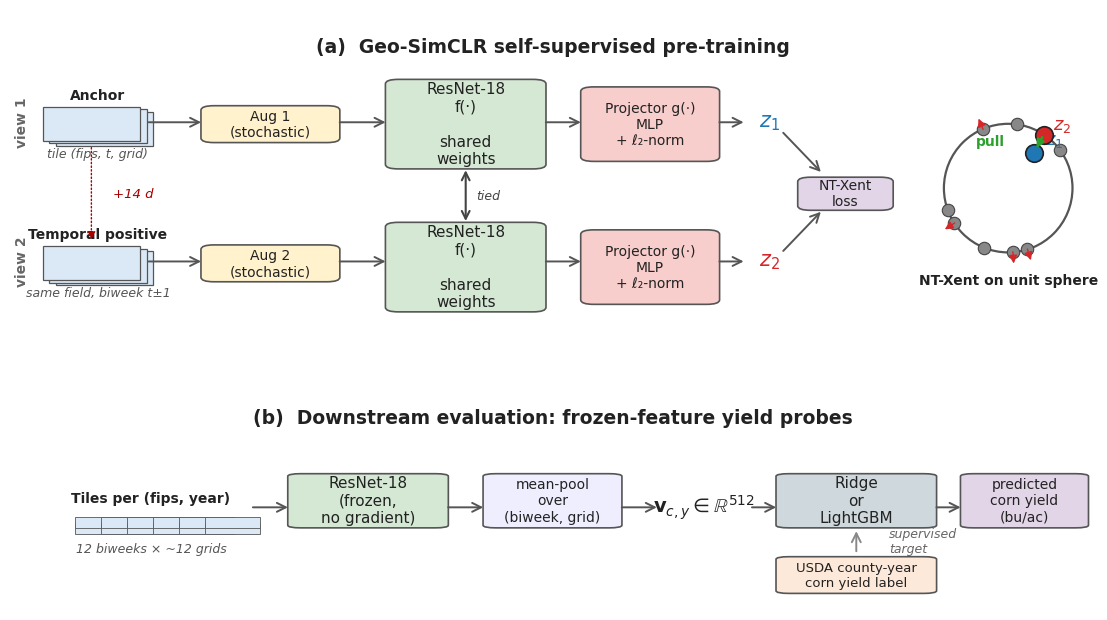

[saved]  final-report\charts\fig01_pipeline.png  (224.4 KB)


In [ ]:
"""fig01_pipeline.png: Geo-SimCLR pipeline schematic.

Stacked 2-panel design (cf. Schroff et al. 2015 "FaceNet"; Hadsell et al. 2006 "Siamese networks"):

Panel A (top, full width)  — SSL pre-training:
    Anchor tile + same-field temporal positive (+14 d) -> independent stochastic augmentations ->
    SHARED ResNet-18 encoder + projection head -> two projections z1 / z2 -> NT-Xent loss,
    visualized as pulling positives together and pushing negatives apart on the unit hypersphere.

Panel B (bottom, full width) — Downstream evaluation:
    For each county-year, all (biweek, grid) tiles -> FROZEN encoder -> mean-pool -> 512-d vector
    -> Ridge / LightGBM probe -> predicted corn yield, supervised by USDA labels.
"""
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Rectangle
from matplotlib.lines import Line2D

out_path = CHARTS / "fig01_pipeline.png"
if not will_skip(out_path):

    fig = plt.figure(figsize=(14, 7.8))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.55, 0.9], hspace=0.02)

    C_INPUT = "#dbe9f6"
    C_AUG   = "#fff2cc"
    C_ENC   = "#d5e8d4"
    C_PROJ  = "#f8cecc"
    C_LOSS  = "#e1d5e7"
    C_TXT   = "#222"

    def rounded(ax, x, y, w, h, color, label, fontsize=11, edgecolor="#555", lw=1.2):
        rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.4,rounding_size=1.2",
                              linewidth=lw, edgecolor=edgecolor, facecolor=color, zorder=2)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, label, ha="center", va="center",
                fontsize=fontsize, color=C_TXT, zorder=3)

    def tile_icon(ax, x, y, w, h, label_top, label_bot):
        """3-layer stacked-tile icon to suggest a 3-channel image."""
        for k in range(3):
            ax.add_patch(Rectangle((x + k*0.6, y - k*0.6), w, h,
                                   linewidth=0.9, edgecolor="#555", facecolor=C_INPUT,
                                   zorder=2 - k*0.01))
        ax.text(x + w/2 + 0.6, y + h + 1.4, label_top, ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=C_TXT, zorder=3)
        ax.text(x + w/2 + 0.6, y - 1.6, label_bot, ha="center", va="top",
                fontsize=9, color="#555", style="italic", zorder=3)

    def arrow(ax, x1, y1, x2, y2, color="#555", lw=1.4, mut=16, style="->"):
        ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=style,
                                     mutation_scale=mut, linewidth=lw, color=color,
                                     shrinkA=3, shrinkB=3, zorder=4))

    # ===================== PANEL A: SSL pretraining =====================
    axA = fig.add_subplot(gs[0, 0])
    axA.set_xlim(0, 100); axA.set_ylim(0, 100); axA.set_axis_off()

    axA.text(50, 90, "(a)  Geo-SimCLR self-supervised pre-training", ha="center", va="center",
             fontsize=13.5, fontweight="bold", color=C_TXT)

    # --- input tiles ---
    tile_icon(axA, 3, 65,  9, 9, "Anchor",            "tile (fips, t, grid)")
    tile_icon(axA, 3, 28,  9, 9, "Temporal positive", "same field, biweek t±1")
    # +14 d connector
    axA.add_patch(FancyArrowPatch((7.5, 64), (7.5, 38), arrowstyle="-|>",
                                  mutation_scale=12, linewidth=1.0, ls=":",
                                  color="#a00", zorder=4))
    axA.text(9.5, 51, "+14 d", fontsize=9.5, color="#a00", style="italic",
             ha="left", va="center")

    # --- aug boxes ---
    rounded(axA, 18, 65, 12, 9, C_AUG, "Aug 1\n(stochastic)", fontsize=10)
    rounded(axA, 18, 28, 12, 9, C_AUG, "Aug 2\n(stochastic)", fontsize=10)
    arrow(axA, 12.4, 70, 18, 70)
    arrow(axA, 12.4, 33, 18, 33)

    # --- shared encoder (taller boxes so the multi-line label fits comfortably) ---
    rounded(axA, 35, 58, 14, 23, C_ENC, "ResNet-18\nf(·)\n\nshared\nweights", fontsize=11)
    rounded(axA, 35, 20, 14, 23, C_ENC, "ResNet-18\nf(·)\n\nshared\nweights", fontsize=11)
    axA.add_patch(FancyArrowPatch((42, 58), (42, 43), arrowstyle="<->",
                                  mutation_scale=14, linewidth=1.5, color="#444", zorder=5))
    axA.text(43, 50.5, "tied", fontsize=9, color="#444", ha="left", va="center", style="italic")
    arrow(axA, 30, 70, 35, 70)
    arrow(axA, 30, 33, 35, 33)

    # --- projector ---
    rounded(axA, 53, 60, 12, 19, C_PROJ, "Projector g(·)\nMLP\n+ ℓ₂-norm", fontsize=10)
    rounded(axA, 53, 22, 12, 19, C_PROJ, "Projector g(·)\nMLP\n+ ℓ₂-norm", fontsize=10)
    arrow(axA, 49, 70, 53, 70)
    arrow(axA, 49, 33, 53, 33)

    # --- z1 / z2 outputs and arrows to NT-Xent box ---
    axA.text(70, 70, r"$z_1$", fontsize=15, color="#1f77b4", ha="center", va="center", fontweight="bold")
    axA.text(70, 33, r"$z_2$", fontsize=15, color="#d62728", ha="center", va="center", fontweight="bold")
    arrow(axA, 65, 70, 68, 70)
    arrow(axA, 65, 33, 68, 33)

    # --- NT-Xent loss "label" box (lives between z and unit-sphere inset) ---
    rounded(axA, 73, 47, 8, 8, C_LOSS, "NT-Xent\nloss", fontsize=10)
    arrow(axA, 71, 68, 75, 56)
    arrow(axA, 71, 35, 75, 47)

    # --- view-1 / view-2 row labels ---
    axA.text(0.5, 70, "view 1", ha="left", va="center", fontsize=10, color="#666",
             fontweight="bold", rotation=90)
    axA.text(0.5, 33, "view 2", ha="left", va="center", fontsize=10, color="#666",
             fontweight="bold", rotation=90)

    # --- unit-sphere geometry inset (clean placement on the right of panel A) ---
    # Use inset_axes anchored to axA in axes coordinates so it never overlaps the boxes.
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    inset = inset_axes(axA, width="100%", height="100%",
                       bbox_to_anchor=(0.84, 0.10, 0.16, 0.85),
                       bbox_transform=axA.transAxes,
                       borderpad=0)
    inset.set_xlim(-1.35, 1.35); inset.set_ylim(-1.35, 1.35); inset.set_aspect("equal")
    inset.set_xticks([]); inset.set_yticks([])
    for sp in inset.spines.values():
        sp.set_visible(False)
    inset.add_patch(Circle((0, 0), 1, fill=False, lw=1.6, color="#555"))
    # anchor / positive
    inset.scatter([0.4], [0.55], s=160, c="#1f77b4", edgecolors="#222", lw=1.2, zorder=3)
    inset.annotate(r"$z_1$", (0.4, 0.55), xytext=(8, 6), textcoords="offset points",
                   fontsize=13, fontweight="bold", color="#1f77b4")
    inset.scatter([0.55], [0.83], s=160, c="#d62728", edgecolors="#222", lw=1.2, zorder=3)
    inset.annotate(r"$z_2$", (0.55, 0.83), xytext=(7, 4), textcoords="offset points",
                   fontsize=13, fontweight="bold", color="#d62728")
    rng = np.random.default_rng(2)
    neg_th = rng.uniform(-np.pi, np.pi, 8)
    inset.scatter(np.cos(neg_th), np.sin(neg_th), s=80, c="#888",
                  edgecolors="#444", lw=0.8, zorder=2)
    inset.annotate("", xy=(0.42, 0.58), xytext=(0.55, 0.83),
                   arrowprops=dict(arrowstyle="-|>", color="#2ca02c", lw=1.7))
    inset.text(-0.05, 0.72, "pull", fontsize=10, color="#2ca02c",
               fontweight="bold", ha="right", va="center")
    for th in neg_th[:4]:
        x, y = np.cos(th), np.sin(th)
        inset.annotate("", xy=(x*1.22, y*1.22), xytext=(x*0.95, y*0.95),
                       arrowprops=dict(arrowstyle="-|>", color="#d62728", lw=1.0))
    inset.text(0, -1.32, "NT-Xent on unit sphere",
               ha="center", va="top", fontsize=10, color="#222", fontweight="bold")

    # ===================== PANEL B: Downstream =====================
    axB = fig.add_subplot(gs[1, 0])
    axB.set_xlim(0, 100); axB.set_ylim(0, 100); axB.set_axis_off()
    axB.text(50, 88, "(b)  Downstream evaluation: frozen-feature yield probes",
             ha="center", va="center", fontsize=13.5, fontweight="bold", color=C_TXT)

    # county-year tile grid icon (12 small tiles in a 6x2 grid suggesting biweek sequence)
    bw_x0, bw_y0 = 6, 35
    for k in range(6):
        for j in range(2):
            axB.add_patch(Rectangle((bw_x0 + k*2.4, bw_y0 + j*2.4), 5.0, 5.0,
                                    linewidth=0.6, edgecolor="#555", facecolor=C_INPUT, zorder=2))
    axB.text(13, bw_y0 + 13, "Tiles per (fips, year)",
             ha="center", va="bottom", fontsize=10, fontweight="bold", color=C_TXT)
    axB.text(13, bw_y0 - 4, "12 biweeks × ~12 grids",
             ha="center", va="top", fontsize=9, color="#555", style="italic")

    # frozen encoder
    rounded(axB, 26, 38, 14, 24, C_ENC, "ResNet-18\n(frozen,\nno gradient)", fontsize=11)
    arrow(axB, 22, 47, 26, 47)

    # mean-pool
    rounded(axB, 44, 38, 12, 24, "#eef", "mean-pool\nover\n(biweek, grid)", fontsize=10)
    arrow(axB, 40, 47, 44, 47)

    # 512-d vector
    axB.text(64, 47, r"$\mathbf{v}_{c,y} \in \mathbb{R}^{512}$",
             fontsize=14, color="#222", ha="center", va="center", fontweight="bold")
    arrow(axB, 56, 47, 60, 47)

    # probe
    rounded(axB, 71, 38, 14, 24, "#cfd8dc", "Ridge\nor\nLightGBM", fontsize=11)
    arrow(axB, 68, 47, 71, 47)

    # predicted yield (taller box so the 3-line label fits)
    rounded(axB, 88, 38, 11, 24, C_LOSS, "predicted\ncorn yield\n(bu/ac)", fontsize=10)
    arrow(axB, 85, 47, 88, 47)

    # USDA label fed in below as supervised target
    rounded(axB, 71, 8, 14, 16, "#fde9d9", "USDA county-year\ncorn yield label", fontsize=9.5)
    arrow(axB, 78, 25, 78, 38, color="#888")
    axB.text(81, 31.5, "supervised\ntarget", fontsize=9, color="#666",
             style="italic", ha="left", va="center")

    plt.savefig(out_path, dpi=DPI_SAVE, bbox_inches="tight", facecolor="white")
    show_and_close(fig)
    saved(out_path)

Anchor h5: data\raw\cropnet\Sentinel-2 Imagery\data\AG\2021\IA\Agriculture_19_IA_2021-07-01_2021-09-30.h5
Positive h5: data\raw\cropnet\Sentinel-2 Imagery\data\AG\2021\IA\Agriculture_19_IA_2021-07-01_2021-09-30.h5


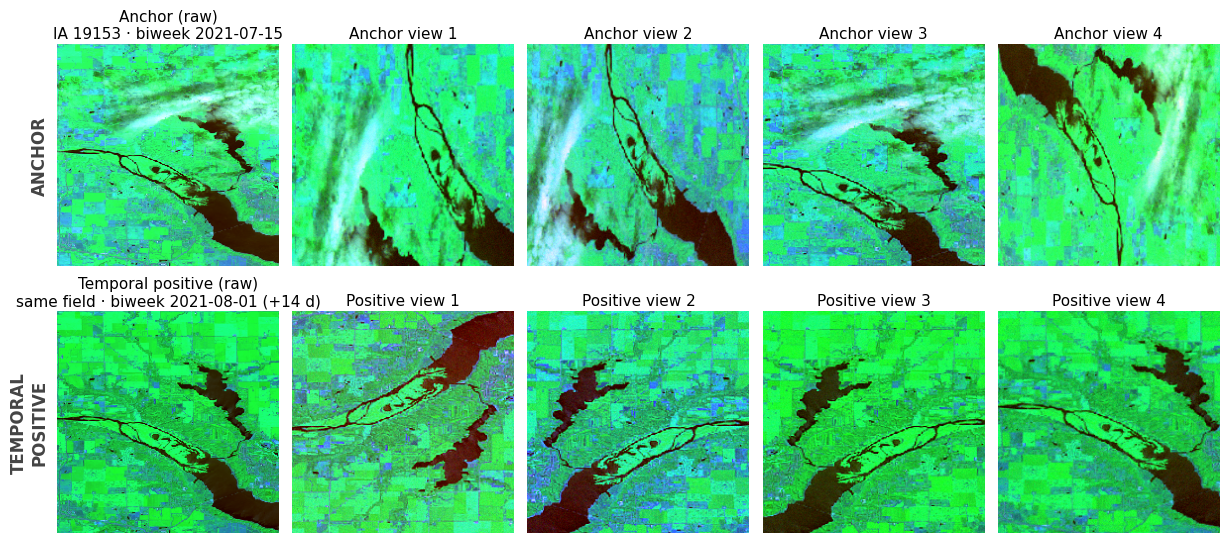

[saved]  final-report\charts\fig02_augmentation_examples.png  (4018.5 KB)


In [ ]:
"""fig02_augmentation_examples.png: real Sentinel-2 tiles with augmentations.

Loads a single (fips, year, biweek, grid) anchor + its temporal positive (same field, +14 days)
from CropNet HDF5, applies 4 independent draws of the Geo-SimCLR augmentation pipeline
(matching notebook 04 verbatim), and renders them in agriculture false color
(SWIR1 -> R, NIR -> G, Blue -> B) with global 2-98 percentile stretch.

Layout: 2 rows x 5 cols. Top row = anchor + 4 augmented anchor views. Bottom row = temporal
positive + 4 augmented positive views. The point: augmentations are non-destructive and the
two views per pair are visibly distinct but plausibly the same field.
"""
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

DATA_RAW = ROOT / "data" / "raw" / "cropnet"

out_path = CHARTS / "fig02_augmentation_examples.png"
if not will_skip(out_path):

    # --- replicate the nb 04 augmentation classes (verbatim parameters) ---
    class GaussianBandNoise(nn.Module):
        def __init__(self, sigma=0.02):
            super().__init__(); self.sigma = sigma
        def forward(self, x):
            return x + torch.randn_like(x) * self.sigma

    class RandomFlexibleCrop(nn.Module):
        def __init__(self, crop_min=160, crop_max=208, out_size=224):
            super().__init__()
            self.crop_min, self.crop_max, self.out_size = crop_min, crop_max, out_size
        def forward(self, x):
            size = int(torch.randint(self.crop_min, self.crop_max + 1, (1,)).item())
            H, W = x.shape[-2:]
            top  = int(torch.randint(0, H - size + 1, (1,)).item())
            left = int(torch.randint(0, W - size + 1, (1,)).item())
            x = x[..., top:top + size, left:left + size]
            return F.interpolate(x.unsqueeze(0), size=self.out_size, mode="bilinear", align_corners=False).squeeze(0)

    class RandomRotate90(nn.Module):
        def __init__(self, prob=0.75):
            super().__init__(); self.prob = prob
        def forward(self, x):
            if torch.rand(1).item() < self.prob:
                k = int(torch.randint(1, 4, (1,)).item())
                x = torch.rot90(x, k=k, dims=(-2, -1))
            return x

    class PerBandIntensityJitter(nn.Module):
        def __init__(self, lo=0.8, hi=1.2, prob=0.8):
            super().__init__()
            self.lo, self.hi, self.prob = float(lo), float(hi), float(prob)
        def forward(self, x):
            if torch.rand(1).item() >= self.prob:
                return x
            scales = torch.empty(x.shape[0], 1, 1, device=x.device).uniform_(self.lo, self.hi)
            return torch.clamp(x * scales, 0.0, 1.0)

    # spatial+photometric pipeline WITHOUT the final z-score (we want to display in [0,1] for FC)
    augment_visual = nn.Sequential(
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        RandomRotate90(prob=0.75),
        RandomFlexibleCrop(160, 208, out_size=224),
        transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=0.5),
        PerBandIntensityJitter(lo=0.8, hi=1.2, prob=0.8),
        GaussianBandNoise(sigma=0.02),
    )

    def to_ag_fc(tile_chw, p_lo=2, p_hi=98):
        """tile_chw is (3, H, W) tensor in [0,1] with channels (Blue, NIR, SWIR1).
        Render in agriculture FC: R<-SWIR1 (ch 2), G<-NIR (ch 1), B<-Blue (ch 0).
        Apply global 2-98 percentile stretch on the whole RGB array (matches nb 06)."""
        rgb = np.stack([
            tile_chw[2].numpy(),  # R = SWIR1
            tile_chw[1].numpy(),  # G = NIR
            tile_chw[0].numpy(),  # B = Blue
        ], axis=-1)
        rgb = np.clip(rgb, 0.0, 1.0)
        lo, hi = np.percentile(rgb, [p_lo, p_hi])
        return np.clip((rgb - lo) / max(hi - lo, 1e-6), 0, 1)

    # --- pick a representative anchor: an Iowa county at biweek 2021-07-15 (peak growing season) ---
    # This county / year is in train (so labelled, well-imaged). 2021 has a partner at 2021-08-01.
    target_state = "IA"
    target_fips  = 19153  # Polk County, IA - same county we used for PCA trajectory in nb 06 (#5)
    target_year  = 2021
    target_biweek_anchor   = "2021-07-15"
    target_biweek_positive = "2021-08-01"
    target_grid  = 0

    anchor_idx = df_county_idx.query(
        "state == @target_state and fips == @target_fips and year == @target_year and biweek == @target_biweek_anchor"
    ).iloc[0]
    pos_idx = df_county_idx.query(
        "state == @target_state and fips == @target_fips and year == @target_year and biweek == @target_biweek_positive"
    ).iloc[0]

    anchor_h5 = DATA_RAW / anchor_idx['h5_path']
    pos_h5    = DATA_RAW / pos_idx['h5_path']
    print(f"Anchor h5: {anchor_h5.relative_to(ROOT)}")
    print(f"Positive h5: {pos_h5.relative_to(ROOT)}")

    with h5py.File(anchor_h5, "r") as fa, h5py.File(pos_h5, "r") as fp:
        anchor_uint8 = fa[str(target_fips)][target_biweek_anchor]["data"][target_grid]
        pos_uint8    = fp[str(target_fips)][target_biweek_positive]["data"][target_grid]

    # uint8 (H, W, 3) -> torch (3, H, W) in [0, 1]
    anchor = torch.from_numpy(anchor_uint8.transpose(2, 0, 1).copy()).float() / 255.0
    positive = torch.from_numpy(pos_uint8.transpose(2, 0, 1).copy()).float() / 255.0

    # generate 4 augmented views per tile (deterministic seed for reproducibility)
    torch.manual_seed(7)
    aug_views_anchor = [augment_visual(anchor).clamp(0, 1) for _ in range(4)]
    aug_views_pos    = [augment_visual(positive).clamp(0, 1) for _ in range(4)]

    # plot
    n_cols = 5
    fig, axes = plt.subplots(2, n_cols, figsize=(15, 6.4),
                             gridspec_kw={"wspace": 0.06, "hspace": 0.18})

    # row 1: anchor
    axes[0, 0].imshow(to_ag_fc(anchor)); axes[0, 0].set_title(
        f"Anchor (raw)\n{target_state} {target_fips} · biweek {target_biweek_anchor}",
        fontsize=11, pad=4)
    for j, view in enumerate(aug_views_anchor, start=1):
        axes[0, j].imshow(to_ag_fc(view))
        axes[0, j].set_title(f"Anchor view {j}", fontsize=11, pad=4)

    # row 2: positive
    axes[1, 0].imshow(to_ag_fc(positive)); axes[1, 0].set_title(
        f"Temporal positive (raw)\nsame field · biweek {target_biweek_positive} (+14 d)",
        fontsize=11, pad=4)
    for j, view in enumerate(aug_views_pos, start=1):
        axes[1, j].imshow(to_ag_fc(view))
        axes[1, j].set_title(f"Positive view {j}", fontsize=11, pad=4)

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    # short row labels on the left (extended description goes in the LaTeX caption)
    axes[0, 0].set_ylabel("ANCHOR", fontsize=12, color="#444", labelpad=6, fontweight="bold")
    axes[1, 0].set_ylabel("TEMPORAL\nPOSITIVE",
                          fontsize=12, color="#444", labelpad=6, fontweight="bold")

    plt.savefig(out_path, dpi=DPI_SAVE, bbox_inches="tight", facecolor="white")
    show_and_close(fig)
    saved(out_path)

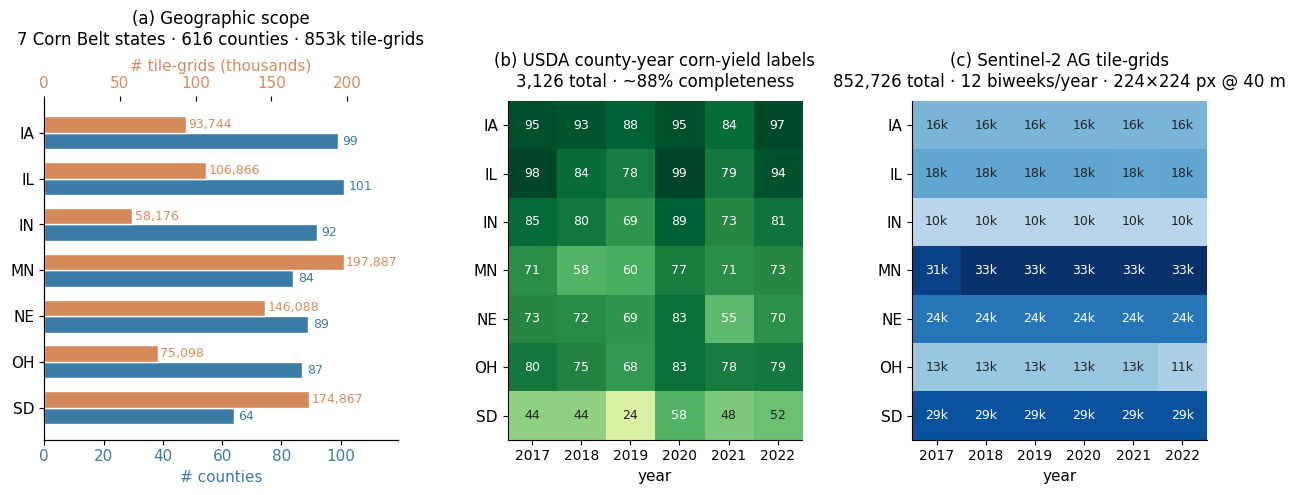

[saved]  final-report\charts\fig03_data_summary.png  (172.6 KB)


In [ ]:
"""fig03_data_summary.png: dataset scope and label coverage.

3-panel figure:
(a) Geographic scope: counties + grids per state (horizontal bar chart, 7 states).
(b) USDA corn-yield labels per (state, year) heatmap (3 126 total, ~88% completeness).
(c) Tile counts per (state, year) heatmap (852 726 total grid tiles).
"""
out_path = CHARTS / "fig03_data_summary.png"
if not will_skip(out_path):

    # consistent state order across all 3 panels: alphabetical
    states_order = ['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD']

    # (a) per-state county and grid counts (use the same state order as panels b and c)
    state_summary = (
        df_county_idx.groupby('state')
        .agg(counties=('fips', 'nunique'),
             tiles=('n_grids', 'sum'))
        .reindex(states_order)
        .reset_index()
        # keep alphabetical top-to-bottom by reversing the y-axis order at plot time
    )

    # (b) USDA yield labels per (state, year)
    df_yield2 = df_yield.copy()
    df_yield2['state'] = df_yield2['state_name'].map({
        'IOWA': 'IA', 'ILLINOIS': 'IL', 'INDIANA': 'IN',
        'MINNESOTA': 'MN', 'NEBRASKA': 'NE', 'OHIO': 'OH', 'SOUTH DAKOTA': 'SD',
    })
    yield_pivot = (
        df_yield2.groupby(['state', 'year'])
        .size().unstack(fill_value=0)
        .reindex(index=states_order)
    )

    # (c) tile counts per (state, year)
    tile_pivot = (
        df_county_idx.groupby(['state', 'year'])['n_grids']
        .sum().unstack(fill_value=0)
        .reindex(index=states_order)
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4),
                             gridspec_kw={'width_ratios': [1.2, 1.0, 1.0], 'wspace': 0.35})

    # ----- (a) per-state county / tile bar -----
    ax = axes[0]
    # reverse so top-to-bottom matches alphabetical (matplotlib barh stacks from bottom up)
    state_summary = state_summary.iloc[::-1].reset_index(drop=True)
    y_pos = np.arange(len(state_summary))
    bars1 = ax.barh(y_pos - 0.18, state_summary['counties'], height=0.36,
                    color="#3a7ca5", label='Counties', edgecolor='white')
    ax2 = ax.twiny()
    bars2 = ax2.barh(y_pos + 0.18, state_summary['tiles'] / 1000, height=0.36,
                     color="#d68a59", label='Tiles (thousands)', edgecolor='white')
    ax.set_yticks(y_pos); ax.set_yticklabels(state_summary['state'], fontsize=11)
    ax.set_xlabel('# counties', color="#3a7ca5", fontsize=11)
    ax2.set_xlabel('# tile-grids (thousands)', color="#d68a59", fontsize=11)
    ax.tick_params(axis='x', labelcolor="#3a7ca5")
    ax2.tick_params(axis='x', labelcolor="#d68a59")
    # data labels on the bars
    for bar, v in zip(bars1, state_summary['counties']):
        ax.text(v + 1.5, bar.get_y() + bar.get_height()/2, f"{v}",
                va='center', fontsize=9, color="#3a7ca5")
    for bar, v in zip(bars2, state_summary['tiles']):
        ax2.text(v / 1000 + 1.5, bar.get_y() + bar.get_height()/2, f"{int(v):,}",
                 va='center', fontsize=9, color="#d68a59")
    ax.set_title(f"(a) Geographic scope\n7 Corn Belt states · {state_summary['counties'].sum()} counties · {state_summary['tiles'].sum()/1000:.0f}k tile-grids",
                 fontsize=12, pad=10)
    ax.set_xlim(0, state_summary['counties'].max() * 1.18)
    ax2.set_xlim(0, state_summary['tiles'].max() / 1000 * 1.18)

    # ----- (b) USDA label heatmap -----
    ax = axes[1]
    im = ax.imshow(yield_pivot.values, aspect='auto', cmap='YlGn',
                   vmin=0, vmax=yield_pivot.values.max())
    ax.set_xticks(range(yield_pivot.shape[1])); ax.set_xticklabels(yield_pivot.columns, fontsize=10)
    ax.set_yticks(range(yield_pivot.shape[0])); ax.set_yticklabels(yield_pivot.index, fontsize=11)
    ax.set_xlabel('year', fontsize=11)
    for i in range(yield_pivot.shape[0]):
        for j in range(yield_pivot.shape[1]):
            v = yield_pivot.values[i, j]
            ax.text(j, i, str(v), ha='center', va='center',
                    fontsize=9, color="white" if v > yield_pivot.values.max()*0.55 else "#222")
    ax.set_title(f"(b) USDA county-year corn-yield labels\n{int(yield_pivot.values.sum()):,} total · ~88% completeness",
                 fontsize=12, pad=10)

    # ----- (c) tile heatmap -----
    ax = axes[2]
    im2 = ax.imshow(tile_pivot.values / 1000, aspect='auto', cmap='Blues',
                    vmin=0, vmax=tile_pivot.values.max() / 1000)
    ax.set_xticks(range(tile_pivot.shape[1])); ax.set_xticklabels(tile_pivot.columns, fontsize=10)
    ax.set_yticks(range(tile_pivot.shape[0])); ax.set_yticklabels(tile_pivot.index, fontsize=11)
    ax.set_xlabel('year', fontsize=11)
    for i in range(tile_pivot.shape[0]):
        for j in range(tile_pivot.shape[1]):
            v = tile_pivot.values[i, j] / 1000
            ax.text(j, i, f"{v:.0f}k", ha='center', va='center',
                    fontsize=9, color="white" if v > (tile_pivot.values.max()/1000)*0.55 else "#222")
    ax.set_title(f"(c) Sentinel-2 AG tile-grids\n{int(tile_pivot.values.sum()):,} total · 12 biweeks/year · 224×224 px @ 40 m",
                 fontsize=12, pad=10)

    plt.savefig(out_path, dpi=DPI_SAVE, bbox_inches="tight", facecolor="white")
    show_and_close(fig)
    saved(out_path)

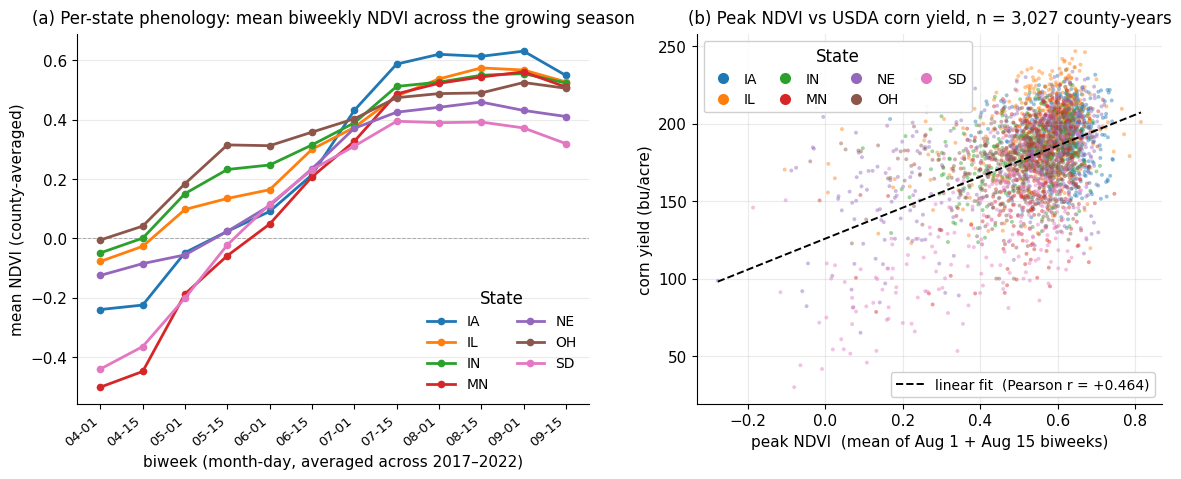

[saved]  final-report\charts\fig04_ndvi_phenology.png  (433.3 KB)


In [ ]:
"""fig04_ndvi_phenology.png: motivates the hand-crafted NDVI baselines.

(a) Mean biweekly NDVI per state across the growing season (Apr-Sep), averaged over years.
    Shows the canonical green-up -> peak (Jul-Aug) -> senescence curve. MN/SD start lower
    in early April due to lingering snow / wet bare soil (documented in nb 03).
(b) Peak NDVI vs corn yield scatter (per county-year), colored by state with Pearson r in title.
    Shows that NDVI captures yield signal but with substantial scatter per state -- motivates
    the SSL representation.
"""
out_path = CHARTS / "fig04_ndvi_phenology.png"
if not will_skip(out_path):

    # (a) per (state, month-day) mean over fips AND years
    df_ndvi2 = df_ndvi.copy()
    df_ndvi2['biweek_dt'] = pd.to_datetime(df_ndvi2['biweek'])
    df_ndvi2['md'] = df_ndvi2['biweek_dt'].dt.strftime('%m-%d')
    ndvi_pivot = (
        df_ndvi2.groupby(['md', 'state'])['ndvi_mean'].mean()
        .unstack('state').sort_index()
    )
    states_order = ['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD']
    ndvi_pivot = ndvi_pivot.reindex(columns=states_order)

    # (b) baseline_features has peak_ndvi + corn_yield + state_name
    state_short = {
        'IOWA': 'IA', 'ILLINOIS': 'IL', 'INDIANA': 'IN',
        'MINNESOTA': 'MN', 'NEBRASKA': 'NE', 'OHIO': 'OH', 'SOUTH DAKOTA': 'SD',
    }
    bf = df_baseline_feats.copy()
    bf['state'] = bf['state_name'].map(state_short)
    bf = bf.dropna(subset=['peak_ndvi', 'corn_yield', 'state'])
    pearson = float(bf['peak_ndvi'].corr(bf['corn_yield']))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8),
                             gridspec_kw={'width_ratios': [1.1, 1.0], 'wspace': 0.22})

    # ---- (a) NDVI phenology curves ----
    ax = axes[0]
    for st in states_order:
        if st not in ndvi_pivot.columns:
            continue
        ax.plot(range(len(ndvi_pivot.index)), ndvi_pivot[st].values,
                marker='o', markersize=4.5, linewidth=2.0, label=st,
                color=STATE_PALETTE[st])
    ax.set_xticks(range(len(ndvi_pivot.index)))
    ax.set_xticklabels([f"{md[:5]}" for md in ndvi_pivot.index], rotation=40, ha='right', fontsize=9.5)
    ax.set_xlabel('biweek (month-day, averaged across 2017–2022)', fontsize=11)
    ax.set_ylabel('mean NDVI (county-averaged)', fontsize=11)
    ax.axhline(0, color='#aaa', lw=0.7, ls='--', zorder=0)
    ax.legend(title='State', frameon=False, ncol=2, fontsize=10, loc='lower right')
    ax.set_title("(a) Per-state phenology: mean biweekly NDVI across the growing season",
                 fontsize=12, pad=8)
    ax.grid(True, alpha=0.25, axis='y')

    # ---- (b) peak NDVI vs yield ----
    ax = axes[1]
    state_handles = []
    for st in states_order:
        sub = bf[bf['state'] == st]
        if sub.empty: continue
        ax.scatter(sub['peak_ndvi'], sub['corn_yield'], s=8, alpha=0.45,
                   color=STATE_PALETTE[st], edgecolors='none')
        state_handles.append(Line2D([0], [0], marker='o', color='none',
                                    markerfacecolor=STATE_PALETTE[st],
                                    markeredgecolor='none', markersize=8, label=st))
    # global linear fit line
    m, b = np.polyfit(bf['peak_ndvi'], bf['corn_yield'], 1)
    xs = np.linspace(bf['peak_ndvi'].min(), bf['peak_ndvi'].max(), 100)
    fit_handle = Line2D([0], [0], color='black', lw=1.4, ls='--',
                        label=f"linear fit  (Pearson r = {pearson:+.3f})")
    ax.plot(xs, m * xs + b, color='black', lw=1.4, ls='--')
    ax.set_xlabel('peak NDVI  (mean of Aug 1 + Aug 15 biweeks)', fontsize=11)
    ax.set_ylabel('corn yield (bu/acre)', fontsize=11)
    # legend with bigger markers, single column outside the data cloud (top-left, where there are no points)
    leg1 = ax.legend(handles=state_handles, title='State', frameon=True, framealpha=0.92,
                     ncol=4, fontsize=10, loc='upper left', columnspacing=1.0,
                     handletextpad=0.5)
    ax.add_artist(leg1)
    ax.legend(handles=[fit_handle], frameon=True, framealpha=0.92, fontsize=10,
              loc='lower right')
    ax.set_title(f"(b) Peak NDVI vs USDA corn yield, n = {len(bf):,} county-years",
                 fontsize=12, pad=8)
    ax.grid(True, alpha=0.25)

    plt.savefig(out_path, dpi=DPI_SAVE, bbox_inches="tight", facecolor="white")
    show_and_close(fig)
    saved(out_path)

## 4. Results figures

- **fig05** — Headline encoder comparison (R², bootstrap 95 % CIs, both splits, NDVI baseline reference line).
- **fig06** — Geo-SimCLR SSL training trajectory (loss / pos_sim / ‖h‖ vs epoch).
- **fig07** — M-PHATE 2-panel: state-coherent geographic clusters + biweek temporal coloring.
- **fig08** — Collapse diagnostic: SVD spectrum + per-county PCA trajectories.
- **fig09** — GradCAM interpretability: 4-wide compact grid (high-yield row + low-yield row, FC + masked overlay).

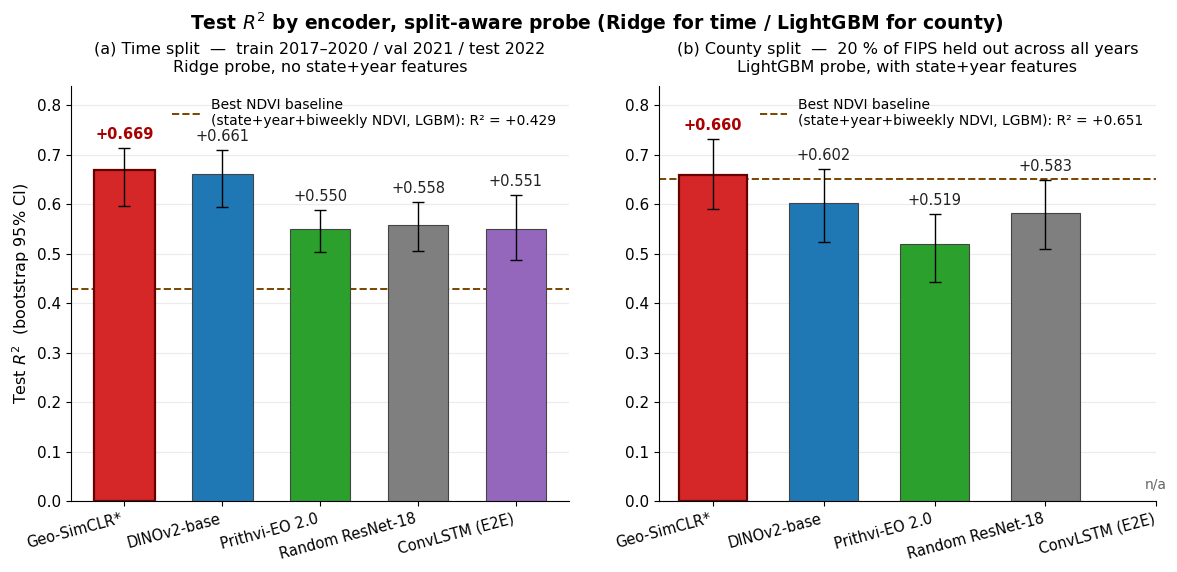

[saved]  final-report\charts\fig05_encoder_comparison.png  (161.3 KB)


In [ ]:
"""fig05_encoder_comparison.png: headline bar chart.

1x2 panels:
  Left  = Time split, Ridge probe, NO state+year features
  Right = County split, LightGBM probe, WITH state+year features

Bars per encoder with bootstrap 95% CI error bars. Horizontal dashed reference line at the
best NDVI baseline R² (state+year + biweekly NDVI, LightGBM). Geo-SimCLR bar highlighted
in red; other DL encoders muted; ConvLSTM E2E shown only on the time panel.
"""
out_path = CHARTS / "fig05_encoder_comparison.png"
if not will_skip(out_path):

    # ---- gather rows (per-encoder split-aware headline cells) ----
    def headline_cell(encoder, split, probe, with_state_year):
        m = (
            (df_results['encoder'] == encoder)
            & (df_results['split'] == split)
            & (df_results['probe'] == probe)
            & (df_results['with_state_year'] == with_state_year)
        )
        sub = df_results[m]
        return None if sub.empty else sub.iloc[0]

    # row order chosen so Geo-SimCLR is leftmost (most prominent)
    panels = [
        ("time",   "(a) Time split  —  train 2017–2020 / val 2021 / test 2022\nRidge probe, no state+year features"),
        ("county", "(b) County split  —  20 % of FIPS held out across all years\nLightGBM probe, with state+year features"),
    ]
    encoder_rows = [
        ("geo_simclr_resnet18", "Geo-SimCLR*",           ENCODER_PALETTE["Geo-SimCLR*"], True),
        ("dinov2_base",         "DINOv2-base",           ENCODER_PALETTE["DINOv2-base"],       False),
        ("prithvi_eo_300m",     "Prithvi-EO 2.0",        ENCODER_PALETTE["Prithvi-EO 2.0"],    False),
        ("random_resnet18",     "Random ResNet-18",      ENCODER_PALETTE["Random ResNet-18"],  False),
        ("ConvLSTM_e2e",        "ConvLSTM (E2E)",        ENCODER_PALETTE["ConvLSTM (E2E)"],    False),
    ]

    # baseline reference
    base_time   = df_baselines.query("baseline == '5_state+year+biweekly NDVI' and split == 'time'").iloc[0]
    base_county = df_baselines.query("baseline == '5_state+year+biweekly NDVI' and split == 'county'").iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.4),
                             gridspec_kw={'wspace': 0.18})

    for ax, (split, title) in zip(axes, panels):
        # collect (label, r2, ci_lo, ci_hi, color, is_ours) per encoder
        rows = []
        for enc_id, label, color, is_ours in encoder_rows:
            if enc_id == "ConvLSTM_e2e":
                row = headline_cell(enc_id, split, "end_to_end", False)
            else:
                if split == "time":
                    row = headline_cell(enc_id, split, "ridge", False)
                else:
                    row = headline_cell(enc_id, split, "lgbm", True)
            if row is None:
                rows.append((label, None, None, None, color, is_ours))
            else:
                rows.append((label, row['r2'], row['r2_ci_lo'], row['r2_ci_hi'], color, is_ours))

        # plot
        x = np.arange(len(rows))
        for i, (label, r2, lo, hi, color, is_ours) in enumerate(rows):
            if r2 is None:
                ax.text(i, 0.02, "n/a", ha='center', va='bottom', fontsize=10, color='#666')
                continue
            err_lo = r2 - lo if lo is not None and not pd.isna(lo) else 0
            err_hi = hi - r2 if hi is not None and not pd.isna(hi) else 0
            edge = "#600" if is_ours else "#444"
            lw = 1.6 if is_ours else 0.8
            bar = ax.bar(i, r2, color=color, edgecolor=edge, linewidth=lw, width=0.62, zorder=2)
            ax.errorbar(i, r2, yerr=[[err_lo], [err_hi]], fmt='none',
                        ecolor='black', elinewidth=1.0, capsize=4, zorder=3)
            # value label above bar
            label_y = (hi if hi is not None and not pd.isna(hi) else r2) + 0.012
            ax.text(i, label_y, f"{r2:+.3f}", ha='center', va='bottom',
                    fontsize=10.5, color=("#a00" if is_ours else "#222"),
                    fontweight=("bold" if is_ours else "normal"))

        ax.set_xticks(x)
        ax.set_xticklabels([r[0] for r in rows],
                           fontsize=10.5, rotation=15, ha='right')
        ax.set_ylabel("Test $R^2$  (bootstrap 95% CI)" if split == "time" else "", fontsize=11.5)
        ax.set_title(title, fontsize=11.5, pad=10)
        ax.set_ylim(0, 0.84)
        ax.axhline(0, color='#bbb', lw=0.8)

        # baseline reference line
        base_r2 = base_time['r2'] if split == "time" else base_county['r2']
        ax.axhline(base_r2, color="#7a4500", lw=1.4, ls='--', zorder=1,
                   label=f"Best NDVI baseline\n(state+year+biweekly NDVI, LGBM): R² = {base_r2:+.3f}")
        ax.legend(loc='upper right', frameon=False, fontsize=10)
        ax.grid(True, axis='y', alpha=0.25)

    fig.suptitle(
        "Test $R^2$ by encoder, split-aware probe (Ridge for time / LightGBM for county)",
        fontsize=13.5, fontweight='bold', y=1.02
    )

    plt.savefig(out_path, dpi=DPI_SAVE, bbox_inches="tight", facecolor="white")
    show_and_close(fig)
    saved(out_path)

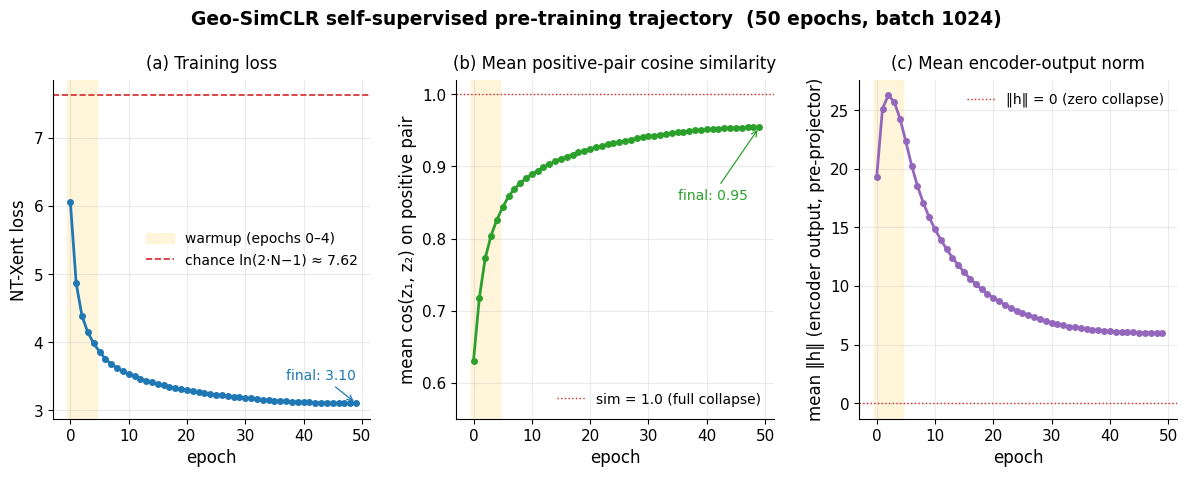

[saved]  final-report\charts\fig06_training_curves.png  (171.1 KB)


In [ ]:
"""fig06_training_curves.png: Geo-SimCLR SSL training trajectory.

3-panel: NT-Xent loss / mean positive cosine similarity / encoder norm vs epoch.
Shaded warmup region (epochs 0-4); chance-level loss line at ln(2N-1) for batch N=1024.
"""
out_path = CHARTS / "fig06_training_curves.png"
if not will_skip(out_path):

    log = df_train_log.copy()
    chance_loss = float(np.log(2 * 1024 - 1))  # NT-Xent chance level for batch size 1024

    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4),
                             gridspec_kw={'wspace': 0.27})

    # ---- (a) loss ----
    ax = axes[0]
    ax.plot(log['epoch'], log['loss'], color="#1f77b4", lw=2.0, marker='o', markersize=4)
    ax.axvspan(-0.5, 4.5, color="#fff2cc", alpha=0.7, zorder=0, label='warmup (epochs 0–4)')
    ax.axhline(chance_loss, color="#d62728", lw=1.2, ls='--', label=f'chance ln(2·N−1) ≈ {chance_loss:.2f}')
    ax.set_xlabel('epoch'); ax.set_ylabel('NT-Xent loss')
    ax.set_title('(a) Training loss', fontsize=12, pad=8)
    ax.legend(frameon=False, fontsize=10, loc='right')
    ax.grid(True, alpha=0.25)

    # final values annotation
    final_loss = log['loss'].iloc[-1]
    ax.annotate(f"final: {final_loss:.2f}",
                xy=(log['epoch'].iloc[-1], final_loss),
                xytext=(log['epoch'].iloc[-1] - 12, final_loss + 0.35),
                fontsize=10, color="#1f77b4",
                arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=0.9))

    # ---- (b) mean positive cosine similarity ----
    ax = axes[1]
    ax.plot(log['epoch'], log['mean_positive_cos_sim'],
            color="#2ca02c", lw=2.0, marker='o', markersize=4)
    ax.axvspan(-0.5, 4.5, color="#fff2cc", alpha=0.7, zorder=0)
    ax.axhline(1.0, color="#d62728", lw=1.0, ls=':', label='sim = 1.0 (full collapse)')
    ax.set_xlabel('epoch'); ax.set_ylabel('mean cos(z₁, z₂) on positive pair')
    ax.set_title('(b) Mean positive-pair cosine similarity', fontsize=12, pad=8)
    ax.legend(frameon=False, fontsize=10, loc='lower right')
    ax.set_ylim(0.55, 1.02)
    ax.grid(True, alpha=0.25)
    final_pos = log['mean_positive_cos_sim'].iloc[-1]
    ax.annotate(f"final: {final_pos:.2f}",
                xy=(log['epoch'].iloc[-1], final_pos),
                xytext=(log['epoch'].iloc[-1] - 14, final_pos - 0.10),
                fontsize=10, color="#2ca02c",
                arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=0.9))

    # ---- (c) encoder norm ----
    ax = axes[2]
    ax.plot(log['epoch'], log['mean_encoder_norm'],
            color="#9467bd", lw=2.0, marker='o', markersize=4)
    ax.axvspan(-0.5, 4.5, color="#fff2cc", alpha=0.7, zorder=0)
    ax.axhline(0, color="#d62728", lw=1.0, ls=':', label='‖h‖ = 0 (zero collapse)')
    ax.set_xlabel('epoch'); ax.set_ylabel('mean ‖h‖ (encoder output, pre-projector)')
    ax.set_title('(c) Mean encoder-output norm', fontsize=12, pad=8)
    ax.legend(frameon=False, fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.25)

    fig.suptitle(
        "Geo-SimCLR self-supervised pre-training trajectory  (50 epochs, batch 1024)",
        fontsize=13.5, fontweight='bold', y=1.04
    )

    plt.savefig(out_path, dpi=DPI_SAVE, bbox_inches="tight", facecolor="white")
    show_and_close(fig)
    saved(out_path)

[mphate] tensor shape (12, 616, 512), fitting M-PHATE (this may take 1–3 min on CPU)...
[mphate] done in 127.8s, output (7392, 2)
[mphate] cached coords to results\tables\mphate_2d_year_avg.parquet


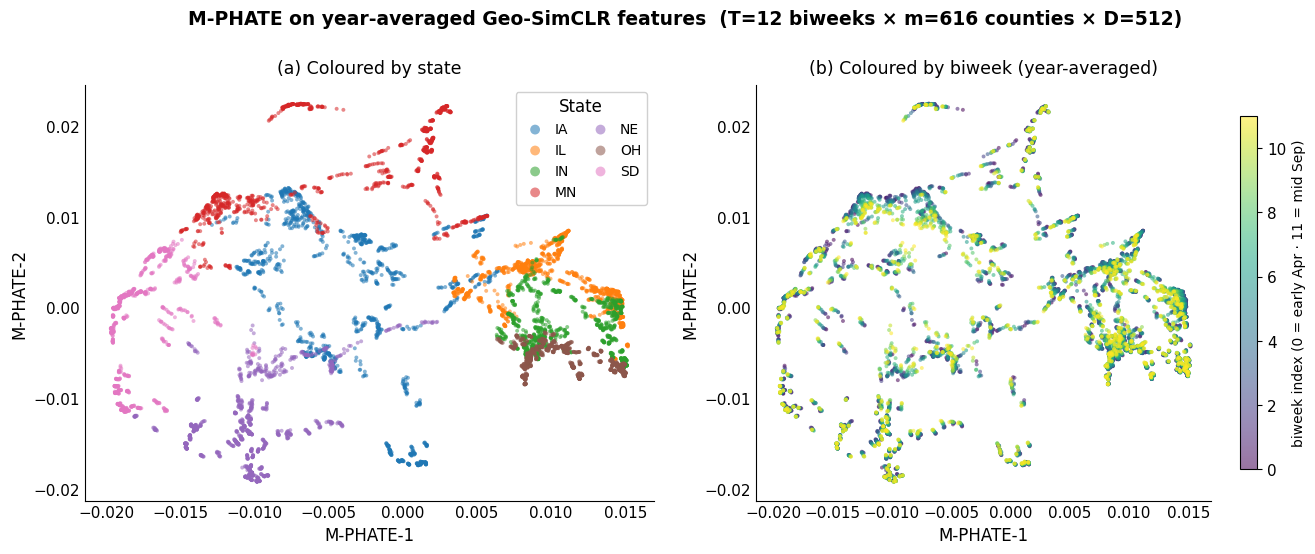

[saved]  final-report\charts\fig07_mphate.png  (576.0 KB)


In [ ]:
"""fig07_mphate.png: M-PHATE 2-panel.

Recipe (matches nb 06 §3): build year-averaged tensor (T=12 biweeks x m counties x 512 dims) from
the L2-normed pooled features, then fit M-PHATE with intraslice_knn=5, interslice_knn=6.

Cache the M-PHATE coordinates on disk so future re-runs of this cell are fast.
"""
import time
out_path = CHARTS / "fig07_mphate.png"
mphate_cache = ROOT / "results" / "tables" / "mphate_2d_year_avg.parquet"

if not will_skip(out_path):
    if df_geosim_pcyb is None:
        print("[fig07] pcyb features missing — skip"); 
    else:
        FEAT_COLS = [c for c in df_geosim_pcyb.columns if c.startswith("feat_")]
        df_pcyb = df_geosim_pcyb.copy()
        # add biweek_idx (0..11) within each year by ranking biweek dates
        df_pcyb['biweek_dt'] = pd.to_datetime(df_pcyb['biweek'])
        df_pcyb['biweek_idx'] = (
            df_pcyb.groupby('year')['biweek_dt'].rank(method='dense').astype(int) - 1
        )

        if mphate_cache.exists() and not FORCE:
            print(f"[mphate] loading cached coords from {mphate_cache.relative_to(ROOT)}")
            mphate_df = pd.read_parquet(mphate_cache)
            mp_2d = mphate_df[['mphate_1','mphate_2']].to_numpy()
            grid_t = mphate_df['biweek_idx'].to_numpy()
            grid_state = mphate_df['state'].to_numpy()
        else:
            import m_phate
            fips_order = sorted(df_pcyb['fips'].unique())
            fips_to_idx = {f: i for i, f in enumerate(fips_order)}
            T = 12
            D = len(FEAT_COLS)
            yr_avg = (
                df_pcyb.groupby(['fips','biweek_idx'], as_index=False)[FEAT_COLS].mean()
            )
            tensor = np.full((T, len(fips_order), D), np.nan, dtype=np.float32)
            for _, row in yr_avg.iterrows():
                t = int(row['biweek_idx'])
                if t < 0 or t >= T: continue
                i = fips_to_idx[int(row['fips'])]
                tensor[t, i, :] = row[FEAT_COLS].to_numpy(dtype=np.float32)
            fill_mean = np.nanmean(tensor, axis=(0,1), keepdims=True)
            tensor = np.where(np.isnan(tensor), fill_mean, tensor)
            print(f"[mphate] tensor shape {tensor.shape}, fitting M-PHATE (this may take 1–3 min on CPU)...")
            t0 = time.time()
            mp_op = m_phate.M_PHATE(n_components=2, intraslice_knn=5, interslice_knn=6,
                                    random_state=0, verbose=0)
            mp_2d = mp_op.fit_transform(tensor)
            print(f"[mphate] done in {time.time()-t0:.1f}s, output {mp_2d.shape}")
            grid_t = np.repeat(np.arange(T), len(fips_order))
            grid_fips = np.tile(np.array(fips_order), T)
            fips_to_state = (
                df_pcyb[['fips','state']].drop_duplicates('fips').set_index('fips')['state'].to_dict()
            )
            grid_state = np.array([fips_to_state.get(f, 'NA') for f in grid_fips])
            # cache
            mphate_df = pd.DataFrame({
                'mphate_1': mp_2d[:,0], 'mphate_2': mp_2d[:,1],
                'biweek_idx': grid_t, 'fips': grid_fips, 'state': grid_state,
            })
            mphate_df.to_parquet(mphate_cache, index=False)
            print(f"[mphate] cached coords to {mphate_cache.relative_to(ROOT)}")

        # plot
        fig, axes = plt.subplots(1, 2, figsize=(16, 5.4),
                                 gridspec_kw={'wspace': 0.18})

        # ----- (a) state coloring -----
        ax = axes[0]
        states_order = ['IA','IL','IN','MN','NE','OH','SD']
        for s in states_order:
            m = grid_state == s
            if not m.any(): continue
            ax.scatter(mp_2d[m,0], mp_2d[m,1], s=8, alpha=0.55,
                       color=STATE_PALETTE[s], label=s, edgecolors='none', rasterized=True)
        ax.legend(title='State', frameon=True, framealpha=0.92, loc='upper right',
                  fontsize=10, markerscale=2.5, ncol=2, columnspacing=0.7,
                  handletextpad=0.4)
        ax.set_title("(a) Coloured by state", fontsize=12.5, pad=8)
        ax.set_xlabel('M-PHATE-1'); ax.set_ylabel('M-PHATE-2')
        ax.tick_params(axis='both', length=0)

        # ----- (b) biweek coloring -----
        ax = axes[1]
        sc = ax.scatter(mp_2d[:,0], mp_2d[:,1], s=8, alpha=0.55,
                        c=grid_t, cmap='viridis', vmin=0, vmax=11,
                        edgecolors='none', rasterized=True)
        cbar = plt.colorbar(sc, ax=ax, ticks=range(0, 12, 2), shrink=0.85)
        cbar.set_label('biweek index (0 = early Apr · 11 = mid Sep)', fontsize=10)
        ax.set_title("(b) Coloured by biweek (year-averaged)", fontsize=12.5, pad=8)
        ax.set_xlabel('M-PHATE-1'); ax.set_ylabel('M-PHATE-2')
        ax.tick_params(axis='both', length=0)

        fig.suptitle(
            "M-PHATE on year-averaged Geo-SimCLR features  (T=12 biweeks × m=616 counties × D=512)",
            fontsize=13.5, fontweight='bold', y=1.02
        )

        plt.savefig(out_path, dpi=DPI_SAVE, bbox_inches="tight", facecolor="white")
        show_and_close(fig)
        saved(out_path)

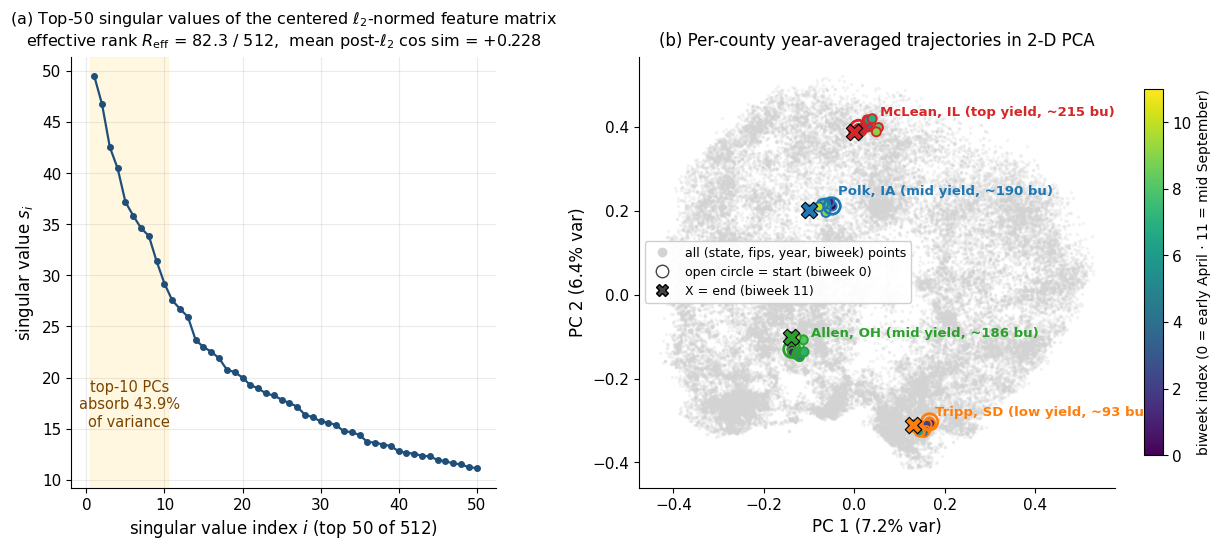

[saved]  final-report\charts\fig08_collapse.png  (536.6 KB)


In [ ]:
"""fig08_collapse.png: two-panel collapse diagnostic.

Aligned to notebook 06 §2 (SVD spectrum) and §5 (per-county PCA trajectories):
- Both panels operate on the L2-normalized feature matrix (NT-Xent geometry),
  not the raw mean-pooled features. Without L2-normalization the singular spectrum
  is dominated by per-row norm variation (range ~[8, 26] pre-norm) and the PCA
  trajectories look qualitatively different.
- Spread metric = mean pairwise PCA-distance for each county's 12 biweek points,
  divided by the global mean pairwise distance over a 5,000-point random subsample
  (same definition as nb 06 §5).
- Start (early-April) marked as an open circle; end (mid-September) as an X.
"""
from sklearn.decomposition import PCA

out_path = CHARTS / "fig08_collapse.png"
if not will_skip(out_path):
    if df_geosim_pcyb is None:
        print("[fig08] features parquet missing — skip")
    else:
        FEAT_COLS = [c for c in df_geosim_pcyb.columns if c.startswith("feat_")]
        X_raw = df_geosim_pcyb[FEAT_COLS].to_numpy(dtype=np.float32)

        # L2-normalize per row (Geo-SimCLR was trained with NT-Xent on cosine similarity)
        norms = np.linalg.norm(X_raw, axis=1)
        X = X_raw / np.maximum(norms[:, None], 1e-12)

        # ---- panel A: SVD spectrum on COLUMN-CENTERED L2-normed matrix (matches nb 06 §2) ----
        Xc = X - X.mean(axis=0, keepdims=True)
        s = np.linalg.svd(Xc, compute_uv=False)
        eff_rank_val = float(df_effrank['eff_rank'].iloc[0])
        top10_var    = float(df_effrank['top10_pct_var'].iloc[0])
        cos_mean     = float(df_effrank['cos_sim_mean'].iloc[0])

        # ---- panel B: per-county 2-D PCA on L2-normed matrix (matches nb 06 §5) ----
        COUNTIES = [
            (17113, "McLean, IL",   "top yield"),
            (19153, "Polk, IA",     "mid yield"),
            (39003, "Allen, OH",    "mid yield"),
            (46123, "Tripp, SD",    "low yield"),
        ]
        pca = PCA(n_components=2, random_state=0).fit(X)
        ev = pca.explained_variance_ratio_
        coords = pca.transform(X)
        df_coord = df_geosim_pcyb[['state','fips','year','biweek']].copy()
        df_coord['pc1'] = coords[:, 0]
        df_coord['pc2'] = coords[:, 1]
        df_coord['biweek_dt'] = pd.to_datetime(df_coord['biweek'])
        df_coord['biweek_idx'] = (
            df_coord.groupby('year')['biweek_dt'].rank(method='dense').astype(int) - 1
        )
        traj = (
            df_coord.groupby(['fips', 'biweek_idx'], as_index=False)[['pc1', 'pc2']].mean()
        )

        # MEAN PAIRWISE DISTANCE (matches nb 06 §5; previous fig08 used RMS by mistake)
        def mean_pairwise(coords_2d):
            if len(coords_2d) < 2:
                return float('nan')
            d = coords_2d[:, None, :] - coords_2d[None, :, :]
            d = np.sqrt((d ** 2).sum(axis=-1))
            iu = np.triu_indices_from(d, k=1)
            return float(d[iu].mean())

        rng = np.random.default_rng(0)
        sub_idx = rng.choice(len(coords), size=min(5000, len(coords)), replace=False)
        global_rms = mean_pairwise(coords[sub_idx])

        per_county_spread = {}
        for fip, _, _ in COUNTIES:
            t = traj[traj['fips'] == fip].sort_values('biweek_idx')
            pts = t[['pc1', 'pc2']].to_numpy()
            per_county_spread[fip] = (mean_pairwise(pts) / global_rms) if len(pts) >= 2 else float('nan')
        spread_pct = [per_county_spread[fip] * 100 for fip, _, _ in COUNTIES]

        # ---- plot ----
        fig, axes = plt.subplots(1, 2, figsize=(15, 5.6),
                                 gridspec_kw={'width_ratios': [1.0, 1.4], 'wspace': 0.28})

        # panel A: SVD spectrum
        ax = axes[0]
        K = 50
        ax.plot(np.arange(1, K + 1), s[:K], marker='o', markersize=4, lw=1.6, color="#1f4e79")
        ax.set_xlabel('singular value index $i$ (top 50 of 512)')
        ax.set_ylabel('singular value $s_i$')
        ax.grid(True, alpha=0.25)
        ax.axvspan(0.5, 10.5, color="#fff2cc", alpha=0.6, zorder=0)
        ax.text(5.5, s[0] * 0.4,
                f"top-10 PCs\nabsorb {top10_var:.1f}%\nof variance",
                ha='center', va='top', fontsize=10.5, color="#7a4500")
        ax.set_title(
            f"(a) Top-50 singular values of the centered $\\ell_2$-normed feature matrix\n"
            f"effective rank $R_\\mathrm{{eff}}$ = {eff_rank_val:.1f} / 512,  mean post-$\\ell_2$ cos sim = {cos_mean:+.3f}",
            fontsize=11.5, pad=8
        )

        # panel B: PCA county trajectories (L2-normed)
        ax = axes[1]
        # mean USDA yield per picked county across all years (rounded to nearest bu/ac for the label)
        mean_yield = (
            df_yield.groupby('fips')['corn_yield'].mean().round().astype(int).to_dict()
        )

        ax.scatter(coords[:, 0], coords[:, 1], s=2, color='lightgrey', alpha=0.18,
                   rasterized=True, zorder=0,
                   label='all (state, fips, year, biweek) points')
        county_colors = ["#d62728", "#1f77b4", "#2ca02c", "#ff7f0e"]
        sc = None
        for (fip, name, ylabel), color in zip(COUNTIES, county_colors):
            t = traj[traj['fips'] == fip].sort_values('biweek_idx')
            if t.empty:
                continue
            ax.plot(t['pc1'], t['pc2'], color=color, lw=1.4, alpha=0.85, zorder=3)
            sc = ax.scatter(t['pc1'], t['pc2'], c=t['biweek_idx'], cmap='viridis',
                            s=42, edgecolors=color, linewidths=1.4, vmin=0, vmax=11, zorder=4)
            # mark start (early April) with open circle, end (mid September) with X
            ax.scatter(t['pc1'].iloc[0], t['pc2'].iloc[0], s=140, marker='o',
                       facecolors='none', edgecolors=color, linewidths=2.0, zorder=5)
            ax.scatter(t['pc1'].iloc[-1], t['pc2'].iloc[-1], s=140, marker='X',
                       c=color, edgecolors='black', linewidths=0.8, zorder=5)
            # inline annotation next to the cluster, color-matched (matches nb 06 §5 styling)
            cx = t['pc1'].mean(); cy = t['pc2'].mean()
            yld = mean_yield.get(int(fip), None)
            yld_str = f", ~{yld} bu" if yld is not None else ""
            ax.annotate(f"{name} ({ylabel}{yld_str})",
                        xy=(cx, cy), xytext=(10, 8), textcoords='offset points',
                        fontsize=9.5, fontweight='bold', color=color, zorder=6)

        if sc is not None:
            cbar = plt.colorbar(sc, ax=ax, ticks=range(0, 12, 2), shrink=0.85)
            cbar.set_label('biweek index (0 = early April · 11 = mid September)', fontsize=10)
        # small in-axes legend explaining the marker shapes + background only
        legend_handles = [
            Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='lightgrey',
                   markeredgecolor='lightgrey', markersize=6,
                   label='all (state, fips, year, biweek) points'),
            Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='none',
                   markeredgecolor='#444', markersize=9,
                   label='open circle = start (biweek 0)'),
            Line2D([0], [0], marker='X', linestyle='none', markerfacecolor='#444',
                   markeredgecolor='black', markersize=9,
                   label='X = end (biweek 11)'),
        ]
        ax.legend(handles=legend_handles, loc='center left', fontsize=9,
                  frameon=True, framealpha=0.92)
        ax.set_xlabel(f"PC 1 ({ev[0] * 100:.1f}% var)")
        ax.set_ylabel(f"PC 2 ({ev[1] * 100:.1f}% var)")
        ax.set_title("(b) Per-county year-averaged trajectories in 2-D PCA",
                     fontsize=12, pad=8)

        plt.savefig(out_path, dpi=DPI_SAVE, bbox_inches="tight", facecolor="white")
        show_and_close(fig)
        saved(out_path)

[fig09] encoder loaded; missing=0, unexpected=0
[fig09] Ridge in-sample R² = +0.800
[fig09] selected 8 county-years


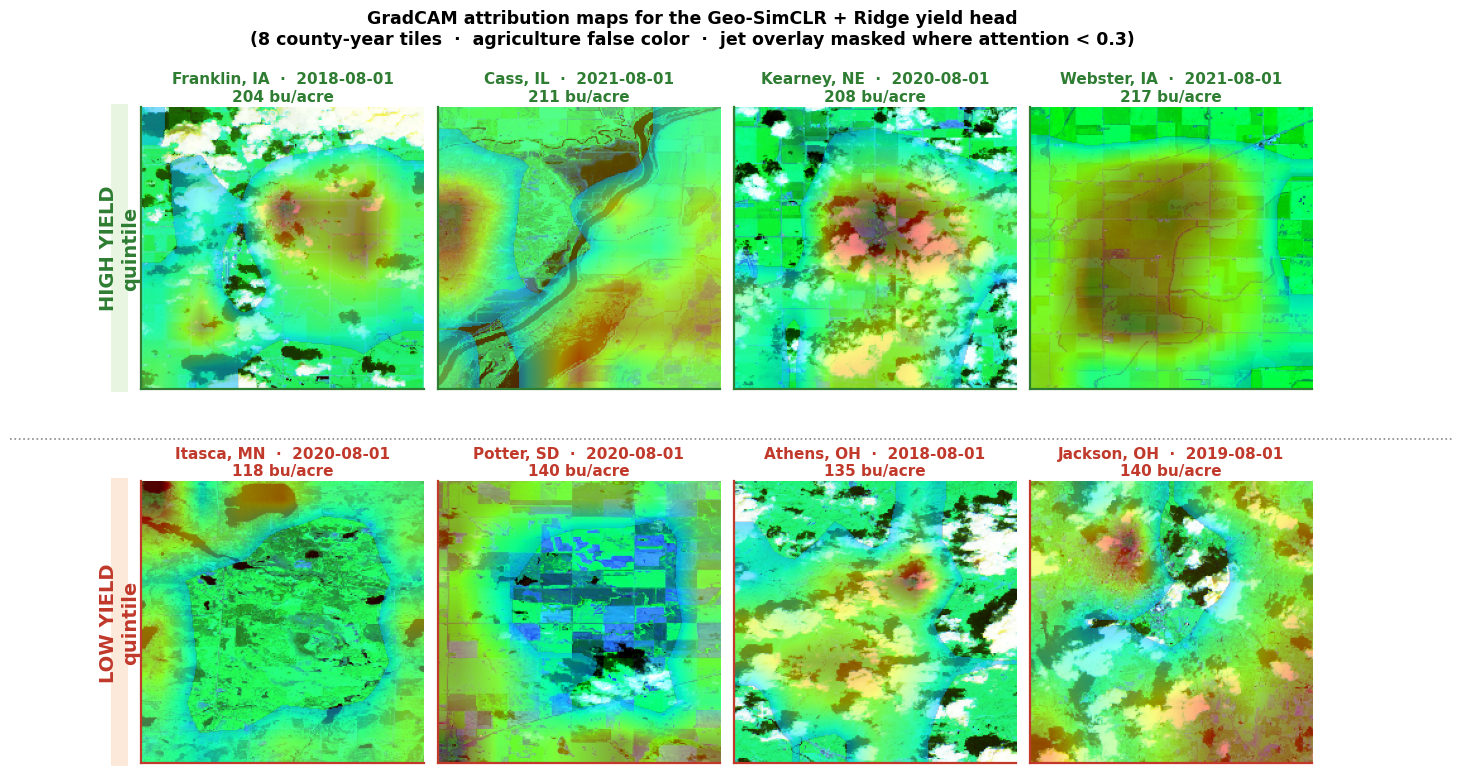

[saved]  final-report\charts\fig09_gradcam.png  (3900.8 KB)


In [ ]:
"""fig09_gradcam.png: 4-wide compact GradCAM grid.

Layout:
- Top row    = 4 highest-yield county-year examples, light green tint
- Bottom row = 4 lowest-yield county-year examples, light orange tint
- Each panel: agriculture FC tile + masked GradCAM overlay in same panel (no separate FC col)
- Short, large titles ("McLean, IL · 2021-08-01 · 221 bu/ac")
- Horizontal divider line + side row labels ("HIGH YIELD" / "LOW YIELD")
"""
import torchvision

out_path = CHARTS / "fig09_gradcam.png"
GEOSIMCLR_BEST_PATH = MODELS / "geo_simclr_resnet18" / "geo_simclr_resnet18_best.pt"

if not will_skip(out_path):
    if not GEOSIMCLR_BEST_PATH.exists():
        print(f"[fig09] encoder weights missing at {GEOSIMCLR_BEST_PATH} -- skip"); 
    else:
        from sklearn.linear_model import Ridge
        from captum.attr import LayerGradCam, LayerAttribution
        from sklearn.metrics import r2_score

        # ---- load encoder ----
        DEVICE = "cpu"  # GradCAM is fast enough on CPU for 8 tiles
        GS_MEAN = torch.tensor(band_stats["mean"], dtype=torch.float32).view(1, 3, 1, 1)
        GS_STD  = torch.tensor(band_stats["std"],  dtype=torch.float32).view(1, 3, 1, 1)

        encoder = torchvision.models.resnet18(weights=None)
        encoder.fc = nn.Identity()
        ckpt = torch.load(GEOSIMCLR_BEST_PATH, map_location="cpu", weights_only=False)
        missing, unexpected = encoder.load_state_dict(ckpt["encoder_state"], strict=False)
        print(f"[fig09] encoder loaded; missing={len(missing)}, unexpected={len(unexpected)}")
        encoder = encoder.to(DEVICE).eval()

        # ---- fit Ridge head on per-county-year features (same recipe as nb 06) ----
        pcy_path = FEATS / "per_county_year" / "geo_simclr_resnet18.parquet"
        pcy = pd.read_parquet(pcy_path).merge(df_yield[['fips','year','corn_yield']], on=['fips','year'], how='inner')
        feat_cols_pcy = [c for c in pcy.columns if c.startswith('feat_')]
        Xp = pcy[feat_cols_pcy].to_numpy(); yp = pcy['corn_yield'].to_numpy()
        ridge = Ridge(alpha=1.0).fit(Xp, yp)
        print(f"[fig09] Ridge in-sample R² = {r2_score(yp, ridge.predict(Xp)):+.3f}")

        # ---- regressor wrapper ----
        class YieldRegressor(nn.Module):
            def __init__(self, backbone, ridge_coef, ridge_intercept):
                super().__init__()
                self.backbone = backbone
                self.head = nn.Linear(512, 1, bias=True)
                with torch.no_grad():
                    self.head.weight.copy_(torch.from_numpy(ridge_coef.astype(np.float32)).view(1, -1))
                    self.head.bias.fill_(float(ridge_intercept))
                for p in self.head.parameters(): p.requires_grad_(False)
                for p in self.backbone.parameters(): p.requires_grad_(False)
            def forward(self, x):
                b = self.backbone
                x = b.conv1(x); x = b.bn1(x); x = b.relu(x); x = b.maxpool(x)
                x = b.layer1(x); x = b.layer2(x); x = b.layer3(x); x = b.layer4(x)
                h = b.avgpool(x).flatten(1)
                return self.head(h).squeeze(-1)

        regressor = YieldRegressor(encoder, ridge.coef_, ridge.intercept_).to(DEVICE).eval()
        gc = LayerGradCam(regressor, regressor.backbone.layer4[-1])

        # ---- pick 4 high + 4 low yield county-years ----
        labeled = pcy[['fips','year','corn_yield']].dropna().copy()
        labeled['bin'] = pd.qcut(labeled['corn_yield'], q=5, labels=False, duplicates='drop')
        high = labeled[labeled['bin'] == labeled['bin'].max()].sample(4, random_state=42)
        low  = labeled[labeled['bin'] == labeled['bin'].min()].sample(4, random_state=43)

        # for each county-year, find a representative biweek/grid (middle of the available index)
        def find_tile(fips, year):
            cand = df_feat_idx[(df_feat_idx['fips'] == fips) & (df_feat_idx['year'] == year)]
            if cand.empty: return None
            mid = cand.iloc[len(cand) // 2]
            # try a peak biweek (Aug 1) preferentially
            preferred = cand[cand['biweek'] == f"{year}-08-01"]
            if not preferred.empty:
                mid = preferred.iloc[len(preferred) // 2]
            return mid

        # county name lookup
        fips_to_name = (
            df_yield.assign(short=df_yield['state_name'].map({
                'IOWA':'IA','ILLINOIS':'IL','INDIANA':'IN','MINNESOTA':'MN',
                'NEBRASKA':'NE','OHIO':'OH','SOUTH DAKOTA':'SD',
            }))[['fips','county_name','short']].drop_duplicates('fips')
            .set_index('fips').to_dict('index')
        )

        # helpers
        def to_ag_fc(tile_uint8):
            rgb = tile_uint8[..., (2, 1, 0)].astype(np.float32)
            lo, hi = np.percentile(rgb, (2, 98))
            return np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)
        def preprocess(tile_uint8):
            x = torch.from_numpy(tile_uint8).permute(2, 0, 1).float().unsqueeze(0) / 255.0
            return (x - GS_MEAN) / GS_STD

        records = []
        for _, r in high.iterrows():
            t = find_tile(int(r['fips']), int(r['year']))
            if t is None: continue
            records.append(dict(label='HIGH', fips=int(r['fips']), year=int(r['year']),
                                biweek=str(t['biweek']), grid_idx=int(t['grid_idx']),
                                h5_path=str(t['h5_path']), corn_yield=float(r['corn_yield'])))
        for _, r in low.iterrows():
            t = find_tile(int(r['fips']), int(r['year']))
            if t is None: continue
            records.append(dict(label='LOW', fips=int(r['fips']), year=int(r['year']),
                                biweek=str(t['biweek']), grid_idx=int(t['grid_idx']),
                                h5_path=str(t['h5_path']), corn_yield=float(r['corn_yield'])))
        print(f"[fig09] selected {len(records)} county-years")

        # ---- compute attributions and render ----
        DATA_RAW2 = ROOT / "data" / "raw" / "cropnet"
        # 4-wide x 2-tall grid; rows separated visually
        fig = plt.figure(figsize=(15.5, 8.6))
        gs = fig.add_gridspec(2, 5, width_ratios=[0.06, 1, 1, 1, 1], wspace=0.06, hspace=0.30)

        # tinted backgrounds per row: high (green), low (orange)
        ROW_TINT = {"HIGH": "#e7f5e1", "LOW": "#fde9d9"}
        ROW_LABEL_COLOR = {"HIGH": "#2e7d32", "LOW": "#c0392b"}

        # left-side strips for row labels
        for r_idx, label in [(0, "HIGH"), (1, "LOW")]:
            ax_strip = fig.add_subplot(gs[r_idx, 0])
            ax_strip.set_facecolor(ROW_TINT[label])
            ax_strip.set_xticks([]); ax_strip.set_yticks([])
            for sp in ax_strip.spines.values():
                sp.set_visible(False)
            label_text = "HIGH YIELD\nquintile" if label == "HIGH" else "LOW YIELD\nquintile"
            ax_strip.text(0.5, 0.5, label_text, ha='center', va='center', rotation=90,
                          fontsize=14, fontweight='bold', color=ROW_LABEL_COLOR[label],
                          transform=ax_strip.transAxes)

        # individual panels
        for k, rec in enumerate(records[:8]):
            r_idx = 0 if rec['label'] == 'HIGH' else 1
            c_idx = (k % 4) + 1  # offset by 1 because col 0 is the strip
            ax = fig.add_subplot(gs[r_idx, c_idx])

            # load tile
            with h5py.File(DATA_RAW2 / rec['h5_path'], "r", rdcc_nbytes=0) as f:
                tile = np.array(f[str(rec['fips'])][rec['biweek']]['data'][rec['grid_idx']], copy=True)

            # GradCAM forward+backward
            x = preprocess(tile).to(DEVICE); x.requires_grad_(True)
            cam = gc.attribute(x).cpu().detach().numpy()[0, 0]
            cam_up = LayerAttribution.interpolate(
                torch.tensor(cam).unsqueeze(0).unsqueeze(0), (224, 224), interpolate_mode="bilinear"
            ).numpy()[0, 0]
            cam_up = (cam_up - cam_up.min()) / (cam_up.max() - cam_up.min() + 1e-8)
            cam_masked = np.ma.masked_where(cam_up < 0.3, cam_up)

            rgb = to_ag_fc(tile)
            ax.imshow(rgb)
            ax.imshow(cam_masked, cmap='jet', alpha=0.5, vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])

            # set tinted background ON THE AXIS via a behind-axis patch + visible spines
            for sp in ax.spines.values():
                sp.set_edgecolor(ROW_LABEL_COLOR[rec['label']])
                sp.set_linewidth(1.6)
            # short title
            cn = fips_to_name.get(rec['fips'], {})
            cname = cn.get('county_name', '?').title()
            cstate = cn.get('short', '?')
            ax.set_title(f"{cname}, {cstate}  ·  {rec['biweek']}\n{int(rec['corn_yield'])} bu/acre",
                         fontsize=11, pad=4,
                         color=ROW_LABEL_COLOR[rec['label']], fontweight='bold')

        # objective title
        fig.suptitle(
            "GradCAM attribution maps for the Geo-SimCLR + Ridge yield head\n"
            "(8 county-year tiles  ·  agriculture false color  ·  jet overlay masked where attention < 0.3)",
            fontsize=12.5, fontweight='bold', y=0.99
        )
        # subtle horizontal divider between top and bottom rows
        fig.add_artist(Line2D([0.06, 0.99], [0.49, 0.49],
                              transform=fig.transFigure, color='#888', lw=1.2, ls=':'))

        plt.savefig(out_path, dpi=DPI_SAVE, bbox_inches="tight", facecolor="white")
        show_and_close(fig)
        saved(out_path)

## 5. Appendix figure

- **figA1** — Plain PHATE 2-panel (corroborates the collapse — ball-shape) + UMAP 3-panel (state / CRD / yield-quintile) compressed into one figure for the appendix.

[figA1] fitting PHATE on 44k x 512 features (1–3 min)...


d:\venv-geosim\Lib\site-packages\graphtools\graphs.py:810: RuntimeWarning: Detected zero distance between 1190 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
d:\venv-geosim\Lib\site-packages\graphtools\graphs.py:505: RuntimeWarning: divide by zero encountered in divide
  scaled = distances_i / bw
d:\venv-geosim\Lib\site-packages\graphtools\graphs.py:505: RuntimeWarning: invalid value encountered in divide
  scaled = distances_i / bw
d:\venv-geosim\Lib\site-packages\graphtools\graphs.py:540: RuntimeWarning: invalid value encountered in divide
  scaled = distances_i / bw
d:\venv-geosim\Lib\site-packages\phate\phate.py:919: RuntimeWarning: Graph is disconnected with 150 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(


[figA1] PHATE done in 16.9s
[figA1] fitting UMAP on 44k x 512 features (1–3 min)...
[figA1] UMAP done in 38.1s


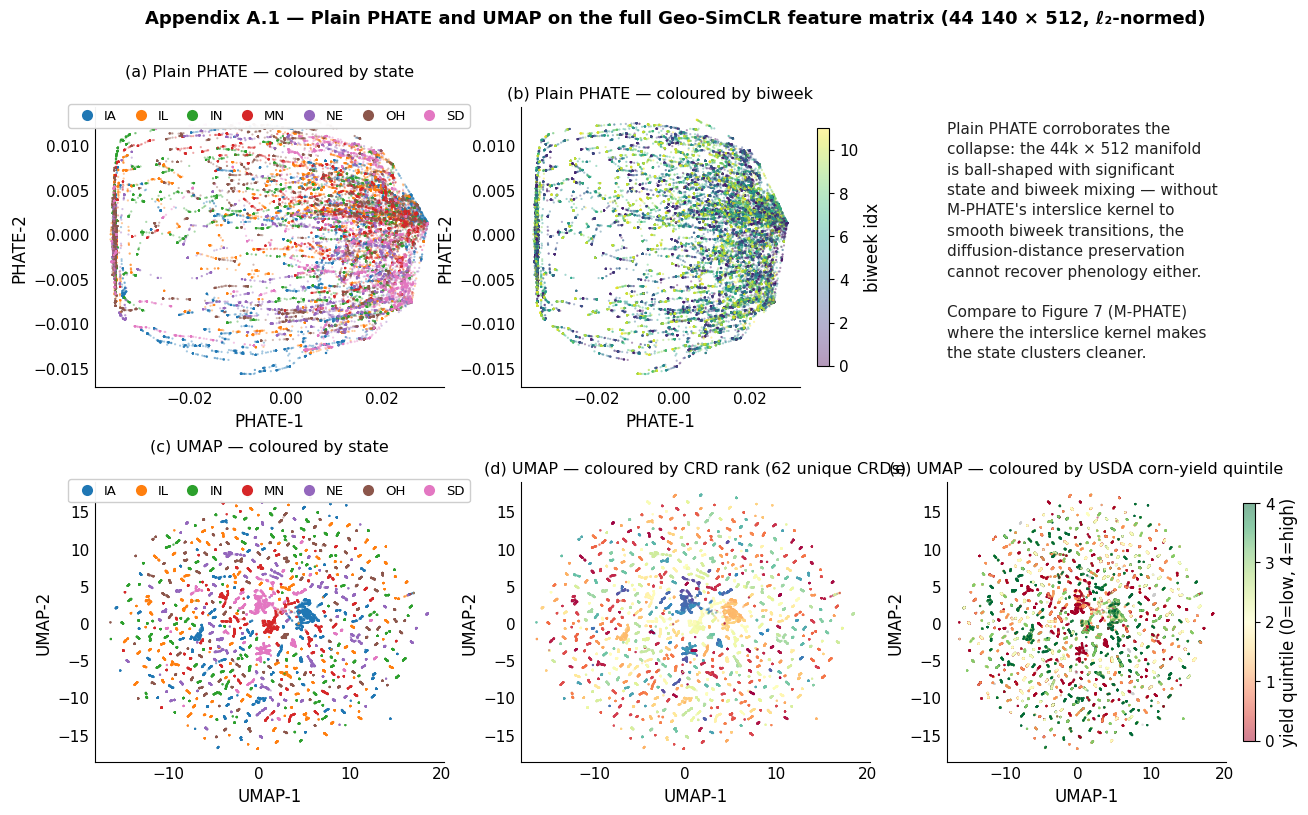

[saved]  final-report\charts\figA1_phate_umap.png  (1243.4 KB)


In [ ]:
"""figA1_phate_umap.png: appendix figure with plain PHATE + UMAP.

Top row (2 panels):  Plain PHATE (knn=5, t='auto') colored by state and by biweek.
Bottom row (3 panels): UMAP (n_neighbors=15, min_dist=0.1) colored by state, CRD, yield quintile.

PHATE and UMAP coordinates are cached as parquets in results/tables/ to avoid recomputing
on subsequent runs. Each takes ~1-3 minutes on CPU at 44k x 512.
"""
out_path = CHARTS / "figA1_phate_umap.png"
phate_cache = ROOT / "results" / "tables" / "phate_2d.parquet"
umap_cache  = ROOT / "results" / "tables" / "umap_2d.parquet"

if not will_skip(out_path):
    if df_geosim_pcyb is None:
        print("[figA1] features parquet missing — skip"); 
    else:
        FEAT_COLS = [c for c in df_geosim_pcyb.columns if c.startswith("feat_")]
        X = df_geosim_pcyb[FEAT_COLS].to_numpy(dtype=np.float32)

        # crosswalks for color
        crd = pd.read_parquet(DATA / "crd_lookup.parquet")[['fips','asd_code','state_ansi']].copy()
        crd['crd_id'] = crd['state_ansi'] * 100 + crd['asd_code']
        df_color = (
            df_geosim_pcyb[['state','fips','year','biweek']]
            .merge(crd[['fips','crd_id']].drop_duplicates('fips'), on='fips', how='left')
            .merge(df_yield[['fips','year','corn_yield']], on=['fips','year'], how='left')
        )
        df_color['biweek_dt'] = pd.to_datetime(df_color['biweek'])
        df_color['biweek_idx'] = (
            df_color.groupby('year')['biweek_dt'].rank(method='dense').astype(int) - 1
        )
        df_color['yield_q'] = pd.qcut(df_color['corn_yield'], q=5, labels=False, duplicates='drop')

        # ---- PHATE ----
        if phate_cache.exists() and not FORCE:
            phate_df = pd.read_parquet(phate_cache)
            ph_2d = phate_df[['ph1','ph2']].to_numpy()
        else:
            import phate
            print("[figA1] fitting PHATE on 44k x 512 features (1–3 min)...")
            t0 = time.time()
            ph_op = phate.PHATE(n_components=2, knn=5, t='auto', random_state=0, verbose=0, n_jobs=-1)
            ph_2d = ph_op.fit_transform(X)
            print(f"[figA1] PHATE done in {time.time()-t0:.1f}s")
            phate_df = pd.DataFrame({'ph1': ph_2d[:,0], 'ph2': ph_2d[:,1]})
            phate_df.to_parquet(phate_cache, index=False)

        # ---- UMAP ----
        if umap_cache.exists() and not FORCE:
            umap_df = pd.read_parquet(umap_cache)
            um_2d = umap_df[['um1','um2']].to_numpy()
        else:
            import umap
            print("[figA1] fitting UMAP on 44k x 512 features (1–3 min)...")
            t0 = time.time()
            um_op = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean', random_state=0)
            um_2d = um_op.fit_transform(X)
            print(f"[figA1] UMAP done in {time.time()-t0:.1f}s")
            umap_df = pd.DataFrame({'um1': um_2d[:,0], 'um2': um_2d[:,1]})
            umap_df.to_parquet(umap_cache, index=False)

        # ---- plot 5-panel figure ----
        fig = plt.figure(figsize=(15.5, 8.5))
        gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], wspace=0.22, hspace=0.34)

        states_order = ['IA','IL','IN','MN','NE','OH','SD']

        # build a shared compact state legend (used by panels a and c)
        state_handles = [Line2D([0], [0], marker='o', linestyle='none',
                                 markerfacecolor=STATE_PALETTE[s],
                                 markeredgecolor='none', markersize=8, label=s)
                          for s in states_order if (df_color['state'].to_numpy() == s).any()]

        # PHATE — state (top-left), biweek (top-middle); top-right = mini explanation panel
        ax = fig.add_subplot(gs[0, 0])
        for s in states_order:
            m = df_color['state'].to_numpy() == s
            if not m.any(): continue
            ax.scatter(ph_2d[m,0], ph_2d[m,1], s=2.5, alpha=0.4,
                       color=STATE_PALETTE[s], edgecolors='none', rasterized=True)
        # compact 7-column legend along the top of the data area, semi-transparent
        ax.legend(handles=state_handles, title=None, frameon=True, framealpha=0.95,
                  loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=7, fontsize=9.5,
                  handletextpad=0.3, columnspacing=0.8, borderaxespad=0.2)
        ax.set_title("(a) Plain PHATE — coloured by state", fontsize=11.5, pad=22)
        ax.set_xlabel('PHATE-1'); ax.set_ylabel('PHATE-2')
        ax.tick_params(axis='both', length=0)

        ax = fig.add_subplot(gs[0, 1])
        sc = ax.scatter(ph_2d[:,0], ph_2d[:,1], s=2.5, alpha=0.4,
                        c=df_color['biweek_idx'], cmap='viridis', vmin=0, vmax=11,
                        edgecolors='none', rasterized=True)
        plt.colorbar(sc, ax=ax, ticks=range(0, 12, 2), shrink=0.85, label='biweek idx')
        ax.set_title("(b) Plain PHATE — coloured by biweek", fontsize=11.5, pad=6)
        ax.set_xlabel('PHATE-1'); ax.set_ylabel('PHATE-2')
        ax.tick_params(axis='both', length=0)

        # explanation text panel (top-right) — kept per user (appendix exception)
        ax = fig.add_subplot(gs[0, 2])
        ax.axis('off')
        ax.text(0.0, 0.95,
                "Plain PHATE corroborates the\ncollapse: the 44k × 512 manifold\nis ball-shaped with significant\nstate and biweek mixing — without\nM-PHATE's interslice kernel to\nsmooth biweek transitions, the\ndiffusion-distance preservation\ncannot recover phenology either.\n\n"
                "Compare to Figure 7 (M-PHATE)\nwhere the interslice kernel makes\nthe state clusters cleaner.",
                ha='left', va='top', fontsize=11, color='#222', linespacing=1.45,
                transform=ax.transAxes)

        # UMAP — state, CRD (rank-coded), yield quintile
        ax = fig.add_subplot(gs[1, 0])
        for s in states_order:
            m = df_color['state'].to_numpy() == s
            if not m.any(): continue
            ax.scatter(um_2d[m,0], um_2d[m,1], s=2.5, alpha=0.4,
                       color=STATE_PALETTE[s], edgecolors='none', rasterized=True)
        ax.legend(handles=state_handles, title=None, frameon=True, framealpha=0.95,
                  loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=7, fontsize=9.5,
                  handletextpad=0.3, columnspacing=0.8, borderaxespad=0.2)
        ax.set_title("(c) UMAP — coloured by state", fontsize=11.5, pad=22)
        ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
        ax.tick_params(axis='both', length=0)

        ax = fig.add_subplot(gs[1, 1])
        crd_codes = df_color['crd_id'].fillna(-1).astype(int).to_numpy()
        # rank-encode CRD ids for visual variety
        unique_crds = np.array(sorted(np.unique(crd_codes)))
        crd_rank = pd.Series(crd_codes).map({c: i for i, c in enumerate(unique_crds)}).to_numpy()
        sc = ax.scatter(um_2d[:,0], um_2d[:,1], s=2.5, alpha=0.4,
                        c=crd_rank, cmap='Spectral', edgecolors='none', rasterized=True)
        ax.set_title(f"(d) UMAP — coloured by CRD rank ({len(unique_crds)} unique CRDs)",
                     fontsize=11.5, pad=6)
        ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
        ax.tick_params(axis='both', length=0)

        ax = fig.add_subplot(gs[1, 2])
        yq = df_color['yield_q'].to_numpy()
        m_lab = ~np.isnan(yq)
        ax.scatter(um_2d[~m_lab, 0], um_2d[~m_lab, 1], s=2.5, alpha=0.15, color='#cccccc',
                   edgecolors='none', rasterized=True, label='(no yield label)')
        sc = ax.scatter(um_2d[m_lab, 0], um_2d[m_lab, 1], s=2.5, alpha=0.5,
                        c=yq[m_lab], cmap='RdYlGn', vmin=0, vmax=4, edgecolors='none', rasterized=True)
        plt.colorbar(sc, ax=ax, ticks=range(5), shrink=0.85, label='yield quintile (0=low, 4=high)')
        ax.set_title("(e) UMAP — coloured by USDA corn-yield quintile", fontsize=11.5, pad=6)
        ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
        ax.tick_params(axis='both', length=0)

        fig.suptitle(
            "Appendix A.1 — Plain PHATE and UMAP on the full Geo-SimCLR feature matrix (44 140 × 512, ℓ₂-normed)",
            fontsize=13, fontweight='bold', y=0.995
        )

        plt.savefig(out_path, dpi=DPI_SAVE, bbox_inches="tight", facecolor="white")
        show_and_close(fig)
        saved(out_path)